# 🎮💰 e스포츠 vs 전통 스포츠: 경제적 규모 비교 분석

---

## 📋 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **대주제** | e스포츠도 스포츠인가? |
| **소주제** | 경제적 규모 비교 |
| **분석 목표** | e스포츠의 경제적 규모가 전통 스포츠와 비교할 수 있는 수준인지 데이터 기반 분석 |
| **비교 대상** | 축구(FIFA), NFL, e스포츠 |

---

## 🎯 주요 분석 질문

1. **선수 개인 수입**: 상위 1% 선수의 수입 격차는 얼마나 되는가?
2. **팀/클럽 가치**: 중위권 e스포츠 팀이 중하위 축구 클럽과 경쟁할 수 있는 규모인가?
3. **성장률**: e스포츠 상금 성장률은 축구/NFL 연봉 상승률과 비교 가능한가?
4. **게임별 분석**: 어떤 e스포츠 게임이 가장 높은 경제적 가치를 보유하는가?

---

## 1️⃣ 라이브러리 로드 및 기본 설정

In [1]:
# ============================================
# 라이브러리 임포트
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
import os

# 통계 분석
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, mannwhitneyu
import statsmodels.api as sm

# 고급 시각화
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (플랫폼 자동 감지)
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 데이터 경로 설정 (상위 폴더의 data 사용)
DATA_PATH = '../data/'

# 출력 디렉토리 생성
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ 라이브러리 로드 완료!')
print(f'📂 데이터 경로: {DATA_PATH}')
print(f'📂 출력 경로: {OUTPUT_DIR}')
print(f'📊 Plotly 사용 가능: {PLOTLY_AVAILABLE}')

✅ 라이브러리 로드 완료!
📂 데이터 경로: ../data/
📂 출력 경로: output
📊 Plotly 사용 가능: True


In [2]:
# ============================================
# 공통 컬러 팔레트 정의
# ============================================
COLORS = {
    'esports': '#9B59B6',      # 보라색 (e스포츠)
    'football': '#27AE60',     # 녹색 (축구)
    'nfl': '#E74C3C',          # 빨간색 (NFL)
    'dota2': '#F44336',        # 빨간색 (Dota 2)
    'lol': '#C9AA71',          # 금색 (LoL)
    'csgo': '#DE9B35',         # 주황색 (CS:GO)
    'fortnite': '#9D4DBB',     # 보라색 (Fortnite)
    'valorant': '#FD4556'      # 빨간색 (Valorant)
}

# 종목별 마커
MARKERS = {
    'esports': 'o',
    'football': 's',
    'nfl': '^'
}

print('✅ 스타일 설정 완료!')

✅ 스타일 설정 완료!


---

## 2️⃣ 데이터 로드

### 📁 사용 데이터셋

| 데이터셋 | 출처 | 용도 |
|----------|------|------|
| Esports Earnings 1998-2023 | [Kaggle](https://www.kaggle.com/datasets/rankirsh/esports-earnings) | e스포츠 상금 분석 |
| eSports Earnings (Players/Teams) | [Kaggle](https://www.kaggle.com/datasets/jackdaoud/esports-earnings-for-players-teams-by-game) | 팀별 상금 분석 |
| FIFA Data for EDA | [Kaggle](https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats/data) | 축구 선수 가치 |
| Football Data: Clubs | [Kaggle](https://www.kaggle.com/datasets/thedevastator/football-data-competitions-clubs-players-statist) | 클럽 가치 |
| NFL Contract Data | [Kaggle](https://www.kaggle.com/datasets/nicholasliusontag/nfl-contract-and-draft-data) | NFL 연봉 |

In [3]:
# ============================================
# 인코딩 자동 감지 함수
# ============================================
def read_csv_auto_encoding(filepath, encodings=['utf-8', 'utf-8-sig', 'cp949', 'euc-kr', 'latin-1']):
    """여러 인코딩을 시도하여 CSV 파일을 읽음"""
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            continue
    # 모든 인코딩 실패 시 latin-1로 강제 읽기
    return pd.read_csv(filepath, encoding='latin-1')

# ============================================
# 실제 데이터 로드
# ============================================
print('📂 데이터 로딩 중...\n')

# 1. e스포츠 데이터
esports_players_raw = read_csv_auto_encoding(f'{DATA_PATH}eSports Earnings/highest_earning_players.csv')
esports_teams_raw = read_csv_auto_encoding(f'{DATA_PATH}eSports Earnings/highest_earning_teams.csv')
esports_general_raw = read_csv_auto_encoding(f'{DATA_PATH}Esports Earnings 1998 - 2023/GeneralEsportData.csv')
esports_historical_raw = read_csv_auto_encoding(f'{DATA_PATH}Esports Earnings 1998 - 2023/HistoricalEsportData.csv')
print('✅ e스포츠 데이터 로드 완료')

# 2. 글로벌 e스포츠 시장 데이터 (신규 추가)
global_esports_market = read_csv_auto_encoding(f'{DATA_PATH}global_gaming_esports_2010_2025.csv')
print('✅ 글로벌 e스포츠 시장 데이터 로드 완료')

# 3. 축구/NFL 데이터
football_salaries_raw = read_csv_auto_encoding(f'{DATA_PATH}football_salaries.csv')
nfl_contracts_raw = read_csv_auto_encoding(f'{DATA_PATH}combined_data_2000-2023.csv')
print('✅ 축구/NFL 계약 데이터 로드 완료')

# 4. FIFA 선수 데이터
fifa_players_raw = read_csv_auto_encoding(f'{DATA_PATH}fifa_eda_stats.csv')
print('✅ FIFA 선수 데이터 로드 완료')

# 5. 실제 축구 선수 시장가치 데이터 (신규 추가)
try:
    football_valuations_raw = pd.read_csv(f'{DATA_PATH}dcereijo-player-scores/player_valuations', encoding='utf-8')
    football_players_raw = pd.read_csv(f'{DATA_PATH}dcereijo-player-scores/players', encoding='utf-8')
    print('✅ 실제 축구 선수 시장가치 데이터 로드 완료')
    HAS_REAL_FOOTBALL_DATA = True
except Exception as e:
    print(f'⚠️ 축구 선수 시장가치 데이터 로드 실패: {e}')
    HAS_REAL_FOOTBALL_DATA = False

print('\n' + '='*60)
print('📊 로드된 데이터셋 요약')
print('='*60)
print(f'   - e스포츠 선수 상금: {len(esports_players_raw):,}행')
print(f'   - e스포츠 팀 상금: {len(esports_teams_raw):,}행')
print(f'   - e스포츠 게임별 통계: {len(esports_general_raw):,}행')
print(f'   - e스포츠 연도별 통계: {len(esports_historical_raw):,}행')
print(f'   - 글로벌 e스포츠 시장: {len(global_esports_market):,}행')
print(f'   - 축구(NFL 스타일) 연봉: {len(football_salaries_raw):,}행')
print(f'   - NFL 계약 데이터: {len(nfl_contracts_raw):,}행')
print(f'   - FIFA 선수 데이터: {len(fifa_players_raw):,}행')
if HAS_REAL_FOOTBALL_DATA:
    print(f'   - 축구 선수 시장가치: {len(football_valuations_raw):,}행')
    print(f'   - 축구 선수 정보: {len(football_players_raw):,}행')

📂 데이터 로딩 중...

✅ e스포츠 데이터 로드 완료
✅ 글로벌 e스포츠 시장 데이터 로드 완료
✅ 축구/NFL 계약 데이터 로드 완료
✅ FIFA 선수 데이터 로드 완료
✅ 실제 축구 선수 시장가치 데이터 로드 완료

📊 로드된 데이터셋 요약
   - e스포츠 선수 상금: 1,000행
   - e스포츠 팀 상금: 928행
   - e스포츠 게임별 통계: 669행
   - e스포츠 연도별 통계: 10,239행
   - 글로벌 e스포츠 시장: 400행
   - 축구(NFL 스타일) 연봉: 5,523행
   - NFL 계약 데이터: 12,629행
   - FIFA 선수 데이터: 18,207행
   - 축구 선수 시장가치: 424,323행
   - 축구 선수 정보: 28,459행


### 📌 데이터 구조 확인

로드된 실제 데이터의 구조를 확인합니다.

In [4]:
# ============================================
# 데이터 구조 확인
# ============================================

print('='*60)
print('🎮 e스포츠 선수 상금 데이터')
print('='*60)
print(f'컬럼: {esports_players_raw.columns.tolist()}')
display(esports_players_raw.head(3))

print('\n' + '='*60)
print('🎮 e스포츠 게임별 통계 데이터')
print('='*60)
print(f'컬럼: {esports_general_raw.columns.tolist()}')
display(esports_general_raw.head(3))

print('\n' + '='*60)
print('⚽ 축구 연봉 데이터 (미식축구 스타일)')
print('='*60)
print(f'컬럼: {football_salaries_raw.columns.tolist()}')
display(football_salaries_raw.head(3))

print('\n' + '='*60)
print('🏈 NFL 계약 데이터')
print('='*60)
print(f'컬럼: {nfl_contracts_raw.columns.tolist()}')
display(nfl_contracts_raw.head(3))

print('\n' + '='*60)
print('⚽ FIFA 선수 데이터')
print('='*60)
print(f'컬럼: {fifa_players_raw.columns.tolist()[:10]}... (총 {len(fifa_players_raw.columns)}개)')
display(fifa_players_raw.head(3))

🎮 e스포츠 선수 상금 데이터
컬럼: ['PlayerId', 'NameFirst', 'NameLast', 'CurrentHandle', 'CountryCode', 'TotalUSDPrize', 'Game', 'Genre']


,PlayerId,NameFirst,NameLast,CurrentHandle,CountryCode,TotalUSDPrize,Game,Genre
0,3883,Peter,Rasmussen,dupreeh,dk,"1,822,989.41",Counter-Strike: Global Offensive,First-Person Shooter
1,3679,Andreas,Højsleth,Xyp9x,dk,"1,799,288.57",Counter-Strike: Global Offensive,First-Person Shooter
2,3885,Nicolai,Reedtz,dev1ce,dk,"1,787,489.88",Counter-Strike: Global Offensive,First-Person Shooter



🎮 e스포츠 게임별 통계 데이터
컬럼: ['Game', 'ReleaseDate', 'Genre', 'TotalEarnings', 'OfflineEarnings', 'PercentOffline', 'TotalPlayers', 'TotalTournaments']


,Game,ReleaseDate,Genre,TotalEarnings,OfflineEarnings,PercentOffline,TotalPlayers,TotalTournaments
0,Age of Empires,1997,Strategy,"736,284.75","522,378.17",0.71,624,341
1,Age of Empires II,1999,Strategy,"3,898,508.73","1,361,409.22",0.35,2256,1939
2,Age of Empires III,2005,Strategy,"122,256.72","44,472.60",0.36,172,179



⚽ 축구 연봉 데이터 (미식축구 스타일)
컬럼: ['position', 'player', 'team', 'age', 'total_value', 'avg_year', 'total_guaranteed', 'fully_guaranteed', 'free_agency']


,position,player,team,age,total_value,avg_year,total_guaranteed,fully_guaranteed,free_agency
0,right-tackle,Trent Brown,Raiders,26,66000000,16500000,36250000,36250000,2023 UFA
1,right-tackle,Ja’Wuan James,Broncos,27,51000000,12750000,32000000,27000000,2023 UFA
2,right-tackle,Lane Johnson,Eagles,29,56250000,11250000,35500000,20862242,2022 Void



🏈 NFL 계약 데이터
컬럼: ['draft_year', 'rnd', 'pick', 'tm', 'player', 'pos', 'g', 'search_key', 'id', 'year_signed', 'signing_tm', 'value', 'value_norm', 'gtd', 'gtd_norm']


,draft_year,rnd,pick,tm,player,pos,g,search_key,id,year_signed,signing_tm,value,value_norm,gtd,gtd_norm
0,2000,1.00,1.00,CLE,Courtney Brown,DE,61.00,"Courtney Brown, DE",0,"2,000.00",Browns,"44,939,436.00",0.72,"10,880,250.00",0.18
1,2000,1.00,1.00,CLE,Courtney Brown,DE,61.00,"Courtney Brown, DE",0,"2,004.00",Browns,"14,700,000.00",0.18,"2,000,000.00",0.02
2,2000,1.00,1.00,CLE,Courtney Brown,DE,61.00,"Courtney Brown, DE",0,"2,003.00",Browns,"20,500,000.00",0.27,"1,000,000.00",0.01



⚽ FIFA 선수 데이터
컬럼: ['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club', 'Value', 'Wage', 'Preferred Foot']... (총 57개)


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,5.00,4.00,4.00,Medium/ Medium,Messi,RF,10.00,"Jul 1, 2004",NaN,2021,5'7,159lbs,84.00,95.00,70.00,90.00,86.00,97.00,93.00,94.00,87.00,96.00,91.00,86.00,91.00,95.00,95.00,85.00,68.00,72.00,59.00,94.00,48.00,22.00,94.00,94.00,75.00,96.00,33.00,28.00,26.00,6.00,11.00,15.00,14.00,8.00,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,5.00,4.00,5.00,High/ Low,C. Ronaldo,ST,7.00,"Jul 10, 2018",NaN,2022,6'2,183lbs,84.00,94.00,89.00,81.00,87.00,88.00,81.00,76.00,77.00,94.00,89.00,91.00,87.00,96.00,70.00,95.00,95.00,88.00,79.00,93.00,63.00,29.00,95.00,82.00,85.00,95.00,28.00,31.00,23.00,7.00,11.00,15.00,14.00,11.00,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,5.00,5.00,5.00,High/ Medium,Neymar,LW,10.00,"Aug 3, 2017",NaN,2022,5'9,150lbs,79.00,87.00,62.00,84.00,84.00,96.00,88.00,87.00,78.00,95.00,94.00,90.00,96.00,94.00,84.00,80.00,61.00,81.00,49.00,82.00,56.00,36.00,89.00,87.00,81.00,94.00,27.00,24.00,33.00,9.00,9.00,15.00,15.00,11.00,€228.1M


---

## 3️⃣ 데이터 탐색 (EDA)

In [5]:
# ============================================
# e스포츠 데이터 전처리 및 확인
# ============================================

# e스포츠 선수 데이터 정리
esports_sample = esports_players_raw.copy()
esports_sample = esports_sample.rename(columns={
    'CurrentHandle': 'Player',
    'TotalUSDPrize': 'Earnings_USD',
    'CountryCode': 'Country'
})

# 상위 선수만 필터링 (상금 기준)
esports_sample = esports_sample.nlargest(100, 'Earnings_USD')

print('='*60)
print('🎮 e스포츠 선수 데이터 (상위 100명)')
print('='*60)
display(esports_sample[['Player', 'Game', 'Earnings_USD', 'Country']].head(10))

print(f'\n📊 기초 통계:')
display(esports_sample['Earnings_USD'].describe())
print(f'\n🎮 게임별 선수 수:')
print(esports_sample['Game'].value_counts())

🎮 e스포츠 선수 데이터 (상위 100명)


,Player,Game,Earnings_USD,Country
100,N0tail,Dota 2,"6,952,596.58",dk
101,JerAx,Dota 2,"6,470,000.02",fi
102,ana,Dota 2,"6,000,411.96",au
103,Ceb,Dota 2,"5,554,297.41",fr
104,Topson,Dota 2,"5,470,902.57",fi
105,KuroKy,Dota 2,"5,193,382.81",de
106,Miracle-,Dota 2,"4,798,043.68",jo
107,MinD_ContRoL,Dota 2,"4,579,118.16",bg
108,GH,Dota 2,"4,193,412.69",lb
109,Matumbaman,Dota 2,"3,765,369.04",fi



📊 기초 통계:


count         100.00
mean    1,976,383.61
std     1,290,340.30
min       913,084.70
25%     1,171,088.30
50%     1,575,877.23
75%     2,083,174.97
max     6,952,596.58
Name: Earnings_USD, dtype: float64


🎮 게임별 선수 수:
Game
Dota 2                              69
Counter-Strike: Global Offensive    14
Fortnite                            13
League of Legends                    4
Name: count, dtype: int64


In [6]:
# ============================================
# 축구(FIFA) 선수 데이터 전처리 및 확인
# ============================================

# FIFA 선수 데이터 정리
football_sample = fifa_players_raw.copy()
football_sample = football_sample.rename(columns={
    'Name': 'Player',
    'Nationality': 'Country'
})

# Value와 Wage 컬럼 변환 (€105.5M, €565K 형식 처리)
def parse_euro_value(val):
    """유로 금액 문자열을 숫자로 변환"""
    if pd.isna(val) or val == '':
        return np.nan
    
    val = str(val)
    
    # 유로 기호 및 특수문자 제거
    val = val.replace('€', '')
    val = val.replace('EUR', '')
    val = val.strip()
    
    # 빈 문자열 체크
    if val == '':
        return np.nan
    
    try:
        if 'M' in val:
            return float(val.replace('M', '')) * 1_000_000
        elif 'K' in val:
            return float(val.replace('K', '')) * 1_000
        else:
            return float(val)
    except:
        return np.nan

# Value와 Wage 컬럼 확인
print('📊 원본 Value/Wage 샘플:')
print(f"   Value 예시: {football_sample['Value'].iloc[0]}")
print(f"   Wage 예시: {football_sample['Wage'].iloc[0]}")

football_sample['Market_Value_EUR'] = football_sample['Value'].apply(parse_euro_value)
football_sample['Wage_EUR_Weekly'] = football_sample['Wage'].apply(parse_euro_value)

# 연간 수입 계산 (주급 × 52주 × 환율 1.08)
football_sample['Annual_Income_USD'] = football_sample['Wage_EUR_Weekly'] * 52 * 1.08

# 데이터 확인
print(f'\n📊 변환 결과:')
print(f"   Market_Value_EUR 유효값: {football_sample['Market_Value_EUR'].notna().sum()}개")
print(f"   Annual_Income_USD 유효값: {football_sample['Annual_Income_USD'].notna().sum()}개")

# 상위 선수만 필터링
football_sample = football_sample.dropna(subset=['Market_Value_EUR', 'Annual_Income_USD'])
football_sample = football_sample.nlargest(100, 'Market_Value_EUR')

print('='*60)
print('⚽ FIFA 축구 선수 데이터 (상위 100명)')
print('='*60)
display(football_sample[['Player', 'Club', 'Market_Value_EUR', 'Annual_Income_USD', 'Age', 'Country']].head(10))

print(f'\n📊 시장가치 기초 통계 (EUR):')
display(football_sample['Market_Value_EUR'].describe())
print(f'\n📊 연간 수입 기초 통계 (USD):')
display(football_sample['Annual_Income_USD'].describe())

📊 원본 Value/Wage 샘플:
   Value 예시: €110.5M
   Wage 예시: €565K

📊 변환 결과:
   Market_Value_EUR 유효값: 18207개
   Annual_Income_USD 유효값: 18207개
⚽ FIFA 축구 선수 데이터 (상위 100명)


,Player,Club,Market_Value_EUR,Annual_Income_USD,Age,Country
2,Neymar Jr,Paris Saint-Germain,"118,500,000.00","16,286,400.00",26,Brazil
0,L. Messi,FC Barcelona,"110,500,000.00","31,730,400.00",31,Argentina
4,K. De Bruyne,Manchester City,"102,000,000.00","19,936,800.00",27,Belgium
5,E. Hazard,Chelsea,"93,000,000.00","19,094,400.00",27,Belgium
15,P. Dybala,Juventus,"89,000,000.00","11,512,800.00",24,Argentina
16,H. Kane,Tottenham Hotspur,"83,500,000.00","11,512,800.00",24,England
25,K. Mbappé,Paris Saint-Germain,"81,000,000.00","5,616,000.00",19,France
7,L. Suárez,FC Barcelona,"80,000,000.00","25,552,800.00",31,Uruguay
17,A. Griezmann,Atlético Madrid,"78,000,000.00","8,143,200.00",27,France
1,Cristiano Ronaldo,Juventus,"77,000,000.00","22,744,800.00",33,Portugal



📊 시장가치 기초 통계 (EUR):


count           100.00
mean     53,480,000.00
std      17,371,740.67
min      35,000,000.00
25%      39,750,000.00
50%      48,250,000.00
75%      62,125,000.00
max     118,500,000.00
Name: Market_Value_EUR, dtype: float64


📊 연간 수입 기초 통계 (USD):


count          100.00
mean    10,626,033.60
std      5,577,710.71
min      1,010,880.00
25%      6,458,400.00
50%      9,828,000.00
75%     13,478,400.00
max     31,730,400.00
Name: Annual_Income_USD, dtype: float64

In [7]:
# ============================================
# NFL 선수 데이터 전처리 및 확인
# ============================================

# NFL 연봉 데이터 정리 (football_salaries_raw 사용)
nfl_sample = football_salaries_raw.copy()
nfl_sample = nfl_sample.rename(columns={
    'player': 'Player',
    'team': 'Team',
    'position': 'Position',
    'avg_year': 'Annual_Salary_USD',
    'total_value': 'Contract_Value_USD',
    'age': 'Age'
})

# 데이터 정리
nfl_sample['Country'] = 'USA'

# 상위 선수 필터링
nfl_sample = nfl_sample.dropna(subset=['Annual_Salary_USD'])
nfl_sample = nfl_sample.nlargest(100, 'Annual_Salary_USD')

print('='*60)
print('🏈 NFL 선수 데이터 (상위 100명)')
print('='*60)
display(nfl_sample[['Player', 'Team', 'Position', 'Annual_Salary_USD', 'Contract_Value_USD']].head(10))

print(f'\n📊 연봉 기초 통계 (USD):')
display(nfl_sample['Annual_Salary_USD'].describe())
print(f'\n🏈 포지션별 선수 수:')
print(nfl_sample['Position'].value_counts().head(10))

🏈 NFL 선수 데이터 (상위 100명)


,Player,Team,Position,Annual_Salary_USD,Contract_Value_USD
1130,Russell Wilson,Seahawks,quarterback,35000000,140000000
1287,Ben Roethlisberger,Steelers,quarterback,34000000,68000000
1288,Aaron Rodgers,Packers,quarterback,33500000,134000000
1289,Matt Ryan,Falcons,quarterback,30000000,150000000
1290,Kirk Cousins,Vikings,quarterback,28000000,84000000
1291,Jimmy Garoppolo,49ers,quarterback,27500000,137500000
1292,Matt Stafford,Lions,quarterback,27000000,135000000
1293,Derek Carr,Raiders,quarterback,25005000,125025000
1458,Drew Brees,Saints,quarterback,25000000,50000000
1459,Andrew Luck,Colts,quarterback,24594000,122970000



📊 연봉 기초 통계 (USD):


count          100.00
mean    18,602,917.66
std      4,359,554.15
min     15,000,000.00
25%     16,000,000.00
50%     16,666,667.00
75%     20,800,000.00
max     35,000,000.00
Name: Annual_Salary_USD, dtype: float64


🏈 포지션별 선수 수:
Position
quarterback                18
defensive-line             16
edge-rusher                13
4-3-defensive-end           9
wide-receiver               9
interior-defensive-line     7
linebacker                  5
3-4-outside-linebacker      4
4-3-defensive-tackle        4
3-4-defensive-end           3
Name: count, dtype: int64


---

## 4️⃣ 데이터 전처리

In [8]:
# ============================================
# 금액 단위 변환 함수
# ============================================
def convert_currency(value):
    """
    금액 문자열을 숫자로 변환
    예: '€105M' → 105000000, '€500K' → 500000
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return value
    
    value = str(value).replace('€', '').replace('$', '').replace(',', '').strip()
    
    if 'M' in value:
        return float(value.replace('M', '')) * 1_000_000
    elif 'K' in value:
        return float(value.replace('K', '')) * 1_000
    else:
        try:
            return float(value)
        except:
            return np.nan

def format_currency(value, unit='$'):
    """
    숫자를 읽기 쉬운 금액 형식으로 변환
    예: 105000000 → '$105.0M'
    """
    if pd.isna(value):
        return 'N/A'
    if value >= 1_000_000_000:
        return f"{unit}{value/1_000_000_000:.1f}B"
    elif value >= 1_000_000:
        return f"{unit}{value/1_000_000:.1f}M"
    elif value >= 1_000:
        return f"{unit}{value/1_000:.1f}K"
    else:
        return f"{unit}{value:.0f}"

# 테스트
print('함수 테스트:')
print(f"  convert_currency('€105M') = {convert_currency('€105M'):,}")
print(f"  format_currency(105000000) = {format_currency(105000000)}")

함수 테스트:
  convert_currency('€105M') = 105,000,000.0
  format_currency(105000000) = $105.0M


In [9]:
# ============================================
# 비교를 위한 통합 데이터 생성
# ============================================

# 축구 데이터 유효성 확인
has_football_data = len(football_sample) > 0

# 통합 비교 데이터프레임
if has_football_data:
    comparison_data = pd.DataFrame({
        'Category': ['e스포츠'] * len(esports_sample) + 
                    ['축구'] * len(football_sample) + 
                    ['NFL'] * len(nfl_sample),
        'Player': list(esports_sample['Player']) + 
                  list(football_sample['Player']) + 
                  list(nfl_sample['Player']),
        'Annual_Income_USD': list(esports_sample['Earnings_USD']) + 
                             list(football_sample['Annual_Income_USD']) + 
                             list(nfl_sample['Annual_Salary_USD'])
    })
else:
    comparison_data = pd.DataFrame({
        'Category': ['e스포츠'] * len(esports_sample) + 
                    ['NFL'] * len(nfl_sample),
        'Player': list(esports_sample['Player']) + 
                  list(nfl_sample['Player']),
        'Annual_Income_USD': list(esports_sample['Earnings_USD']) + 
                             list(nfl_sample['Annual_Salary_USD'])
    })

print('✅ 통합 데이터 생성 완료!')
print(f'\n📊 종목별 선수 수:')
print(comparison_data['Category'].value_counts())
display(comparison_data.head())

✅ 통합 데이터 생성 완료!

📊 종목별 선수 수:
Category
e스포츠    100
축구      100
NFL     100
Name: count, dtype: int64


,Category,Player,Annual_Income_USD
0,e스포츠,N0tail,"6,952,596.58"
1,e스포츠,JerAx,"6,470,000.02"
2,e스포츠,ana,"6,000,411.96"
3,e스포츠,Ceb,"5,554,297.41"
4,e스포츠,Topson,"5,470,902.57"


---

## 5️⃣ 시각화 및 분석

### 5.1 선수 개인 수입 비교

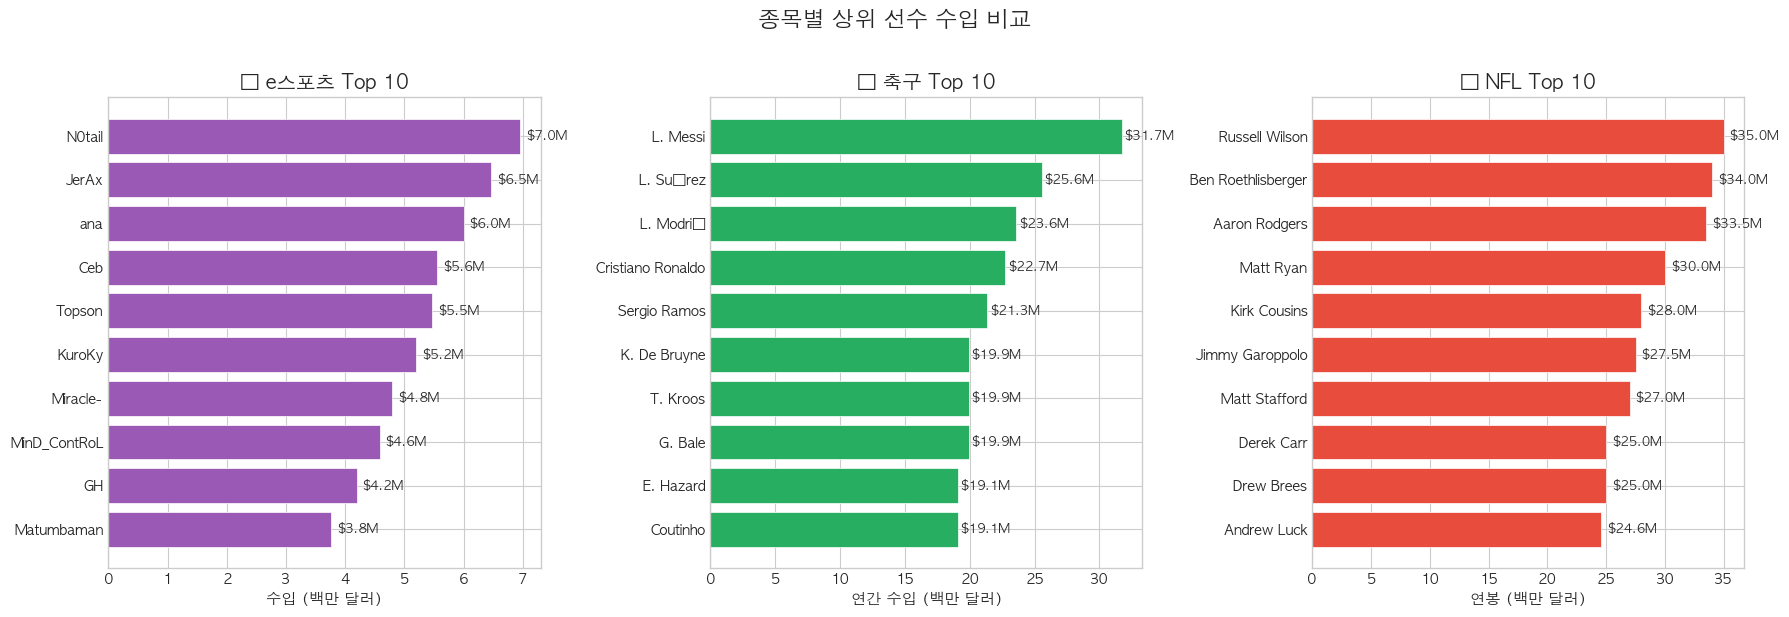


📊 분석 결과:
   - e스포츠 최고 수입: $7.0M
   - 축구 최고 연봉: $31.7M
   - NFL 최고 연봉: $35.0M


In [10]:
# ============================================
# 시각화 1: 종목별 상위 선수 수입 비교 (Bar Chart)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 축구 데이터 유효성 확인
has_football_data = len(football_sample) > 0

if has_football_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes = [axes[0], None, axes[1]]  # 축구 자리 비우기

# e스포츠 Top 10
esports_top = esports_sample.nlargest(10, 'Earnings_USD')
ax_esports = axes[0]
ax_esports.barh(esports_top['Player'], esports_top['Earnings_USD']/1e6, 
             color=COLORS['esports'], edgecolor='white', linewidth=0.5)
ax_esports.set_xlabel('수입 (백만 달러)', fontsize=11)
ax_esports.set_title('🎮 e스포츠 Top 10', fontsize=14, fontweight='bold')
ax_esports.invert_yaxis()
for i, v in enumerate(esports_top['Earnings_USD']/1e6):
    ax_esports.text(v + 0.1, i, f'${v:.1f}M', va='center', fontsize=9)

# 축구 Top 10 (데이터가 있을 경우만)
if has_football_data:
    football_top = football_sample.nlargest(10, 'Annual_Income_USD')
    axes[1].barh(football_top['Player'], football_top['Annual_Income_USD']/1e6, 
                 color=COLORS['football'], edgecolor='white', linewidth=0.5)
    axes[1].set_xlabel('연간 수입 (백만 달러)', fontsize=11)
    axes[1].set_title('⚽ 축구 Top 10', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    for i, v in enumerate(football_top['Annual_Income_USD']/1e6):
        axes[1].text(v + 0.2, i, f'${v:.1f}M', va='center', fontsize=9)

# NFL Top 10
nfl_top = nfl_sample.nlargest(10, 'Annual_Salary_USD')
ax_nfl = axes[2] if has_football_data else axes[2]
if not has_football_data:
    # 2개 서브플롯일 경우 재설정
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # e스포츠 다시 그리기
    esports_top = esports_sample.nlargest(10, 'Earnings_USD')
    axes[0].barh(esports_top['Player'], esports_top['Earnings_USD']/1e6, 
                 color=COLORS['esports'], edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('수입 (백만 달러)', fontsize=11)
    axes[0].set_title('🎮 e스포츠 Top 10', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    for i, v in enumerate(esports_top['Earnings_USD']/1e6):
        axes[0].text(v + 0.1, i, f'${v:.1f}M', va='center', fontsize=9)
    
    ax_nfl = axes[1]

ax_nfl.barh(nfl_top['Player'], nfl_top['Annual_Salary_USD']/1e6, 
         color=COLORS['nfl'], edgecolor='white', linewidth=0.5)
ax_nfl.set_xlabel('연봉 (백만 달러)', fontsize=11)
ax_nfl.set_title('🏈 NFL Top 10', fontsize=14, fontweight='bold')
ax_nfl.invert_yaxis()
for i, v in enumerate(nfl_top['Annual_Salary_USD']/1e6):
    ax_nfl.text(v + 0.5, i, f'${v:.1f}M', va='center', fontsize=9)

plt.suptitle('종목별 상위 선수 수입 비교', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_top_players_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📊 분석 결과:')
print(f"   - e스포츠 최고 수입: ${esports_top['Earnings_USD'].max()/1e6:.1f}M")
if has_football_data:
    print(f"   - 축구 최고 연봉: ${football_top['Annual_Income_USD'].max()/1e6:.1f}M")
print(f"   - NFL 최고 연봉: ${nfl_top['Annual_Salary_USD'].max()/1e6:.1f}M")

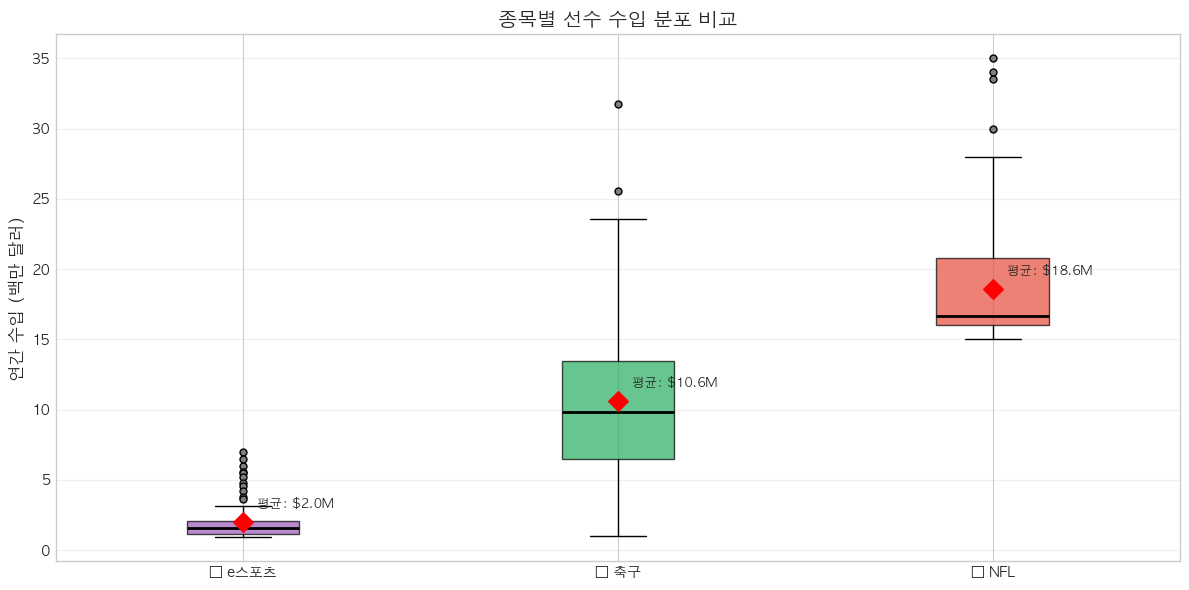


📊 종목별 수입 통계 (백만 달러):


,평균,중앙값,최소,최대
Category,,,,
NFL,18.60,16.67,15.00,35.00
e스포츠,1.98,1.58,0.91,6.95
축구,10.63,9.83,1.01,31.73


In [11]:
# ============================================
# 시각화 2: 종목별 수입 분포 비교 (Box Plot)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 축구 데이터 유효성 확인
has_football_data = len(football_sample) > 0

fig, ax = plt.subplots(figsize=(12, 6))

# 데이터 준비
if has_football_data:
    categories = ['e스포츠', '축구', 'NFL']
    box_data = [comparison_data[comparison_data['Category'] == cat]['Annual_Income_USD']/1e6 
                for cat in categories]
    box_colors = [COLORS['esports'], COLORS['football'], COLORS['nfl']]
    labels = ['🎮 e스포츠', '⚽ 축구', '🏈 NFL']
else:
    categories = ['e스포츠', 'NFL']
    box_data = [comparison_data[comparison_data['Category'] == cat]['Annual_Income_USD']/1e6 
                for cat in categories]
    box_colors = [COLORS['esports'], COLORS['nfl']]
    labels = ['🎮 e스포츠', '🏈 NFL']

# 박스플롯
bp = ax.boxplot(box_data,
                labels=labels,
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=5))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('연간 수입 (백만 달러)', fontsize=12)
ax.set_title('종목별 선수 수입 분포 비교', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 평균값 표시
for i, cat in enumerate(categories, 1):
    mean_val = comparison_data[comparison_data['Category'] == cat]['Annual_Income_USD'].mean()/1e6
    ax.scatter(i, mean_val, color='red', s=100, zorder=5, marker='D', label='평균' if i==1 else '')
    ax.annotate(f'평균: ${mean_val:.1f}M', (i, mean_val), textcoords='offset points', 
                xytext=(10, 10), fontsize=9)

plt.tight_layout()
plt.savefig('02_income_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 통계 요약
print('\n📊 종목별 수입 통계 (백만 달러):')
summary = comparison_data.groupby('Category')['Annual_Income_USD'].agg(['mean', 'median', 'min', 'max'])/1e6
summary.columns = ['평균', '중앙값', '최소', '최대']
display(summary.round(2))

### 5.2 게임별 e스포츠 상금 분석

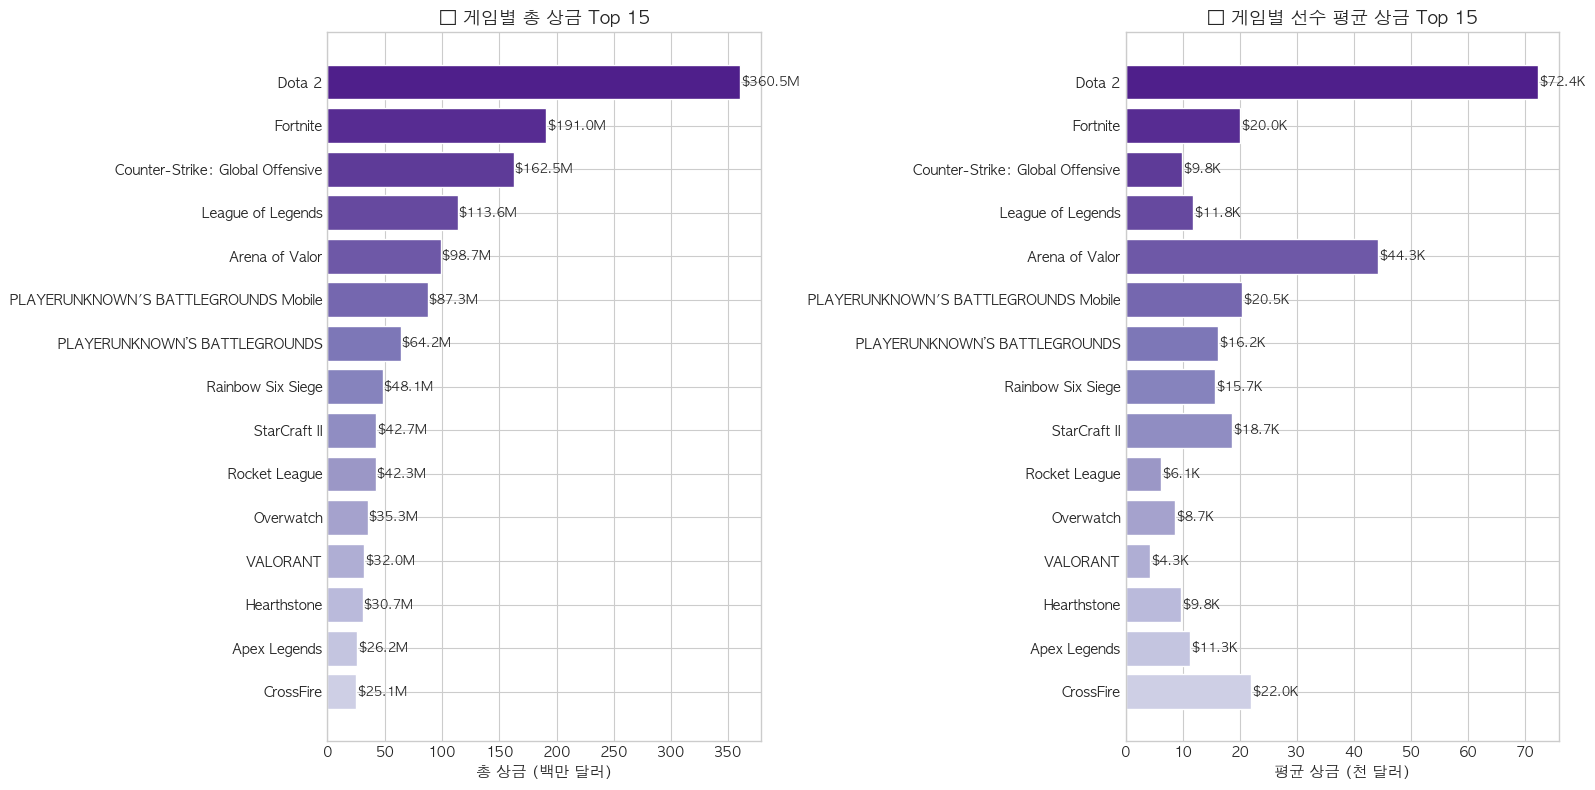


📊 게임별 상금 통계 (상위 15개):


,총 상금,선수 수,대회 수,평균 상금
Game,,,,
Dota 2,"360,461,163.42",4980,1934,"72,381.76"
Fortnite,"191,012,698.69",9535,2291,"20,032.79"
Counter-Strike: Global Offensive,"162,489,706.76",16518,7033,"9,837.13"
League of Legends,"113,596,024.63",9588,3000,"11,847.73"
Arena of Valor,"98,746,138.92",2231,179,"44,260.93"
PLAYERUNKNOWN'S BATTLEGROUNDS Mobile,"87,322,954.82",4263,341,"20,483.92"
PLAYERUNKNOWN’S BATTLEGROUNDS,"64,200,450.19",3967,631,"16,183.63"
Rainbow Six Siege,"48,130,526.59",3070,568,"15,677.70"
StarCraft II,"42,692,707.57",2280,7510,"18,724.87"


In [12]:
# ============================================
# 시각화 3: 게임별 e스포츠 상금 비교 (실제 데이터)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# esports_general_raw에서 상위 게임 추출
game_stats = esports_general_raw.nlargest(15, 'TotalEarnings')[['Game', 'TotalEarnings', 'TotalPlayers', 'TotalTournaments']].copy()
game_stats = game_stats.rename(columns={
    'TotalEarnings': '총 상금',
    'TotalPlayers': '선수 수',
    'TotalTournaments': '대회 수'
})
game_stats['평균 상금'] = game_stats['총 상금'] / game_stats['선수 수']
game_stats = game_stats.set_index('Game')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 게임별 총 상금
colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(game_stats)))[::-1]
axes[0].barh(game_stats.index, game_stats['총 상금']/1e6, color=colors, edgecolor='white')
axes[0].set_xlabel('총 상금 (백만 달러)', fontsize=11)
axes[0].set_title('🎮 게임별 총 상금 Top 15', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, (game, row) in enumerate(game_stats.iterrows()):
    axes[0].text(row['총 상금']/1e6 + 0.5, i, f"${row['총 상금']/1e6:.1f}M", va='center', fontsize=9)

# 게임별 평균 상금
axes[1].barh(game_stats.index, game_stats['평균 상금']/1e3, color=colors, edgecolor='white')
axes[1].set_xlabel('평균 상금 (천 달러)', fontsize=11)
axes[1].set_title('🎮 게임별 선수 평균 상금 Top 15', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
for i, (game, row) in enumerate(game_stats.iterrows()):
    axes[1].text(row['평균 상금']/1e3 + 0.2, i, f"${row['평균 상금']/1e3:.1f}K", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_esports_by_game.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📊 게임별 상금 통계 (상위 15개):')
display(game_stats)

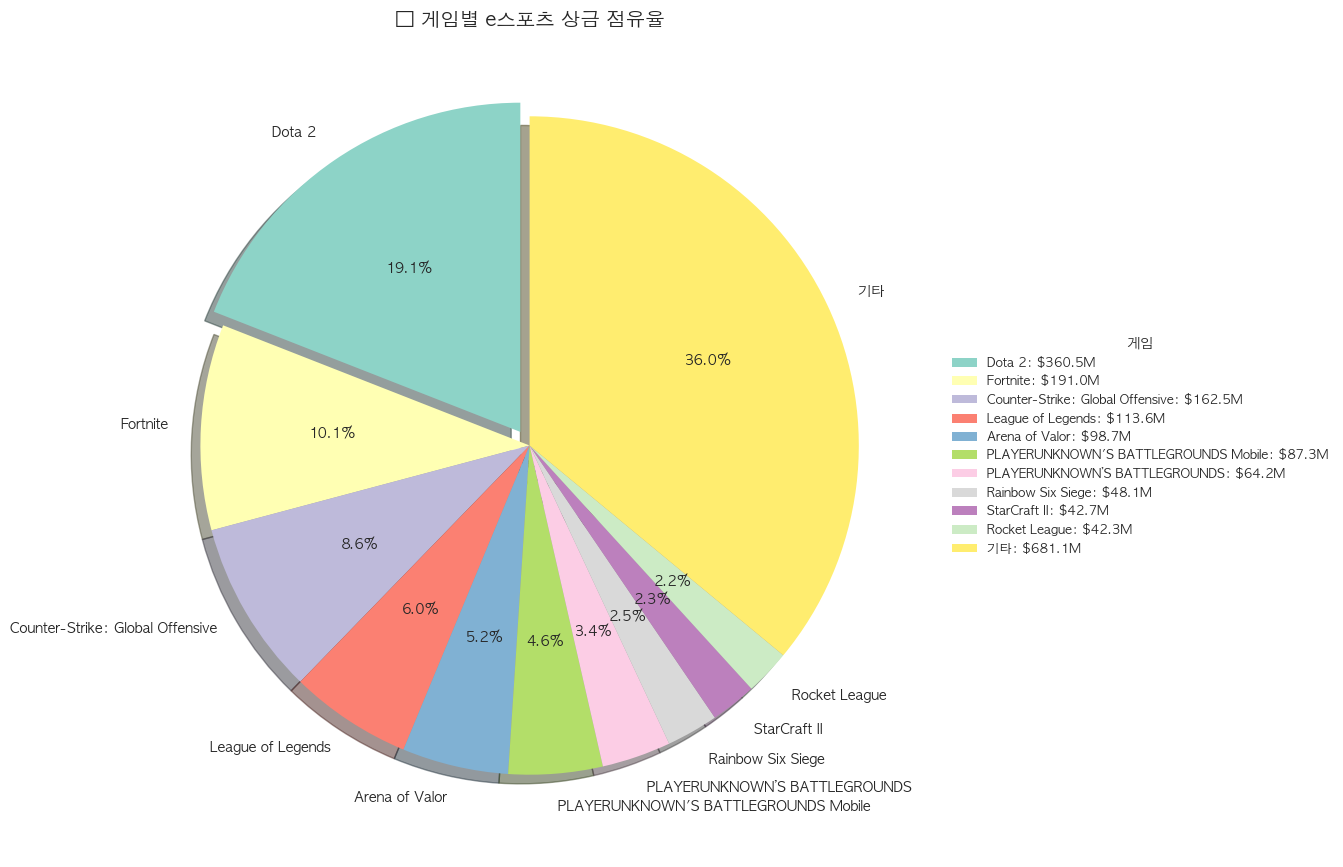


📊 전체 e스포츠 상금 총액: $1.9B


In [13]:
# ============================================
# 시각화 4: 게임별 상금 점유율 (Pie Chart)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


# 상위 10개 게임과 기타로 분류
game_earnings = esports_general_raw.nlargest(10, 'TotalEarnings')[['Game', 'TotalEarnings']].copy()
others_total = esports_general_raw.nsmallest(len(esports_general_raw)-10, 'TotalEarnings')['TotalEarnings'].sum()
game_earnings = pd.concat([
    game_earnings,
    pd.DataFrame({'Game': ['기타'], 'TotalEarnings': [others_total]})
], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 10))

# 색상 설정
colors = plt.cm.Set3(np.linspace(0, 1, len(game_earnings)))

wedges, texts, autotexts = ax.pie(
    game_earnings['TotalEarnings'], 
    labels=game_earnings['Game'],
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.05 if i == 0 else 0 for i in range(len(game_earnings))],
    shadow=True,
    startangle=90
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('🎮 게임별 e스포츠 상금 점유율', fontsize=14, fontweight='bold')

# 범례에 금액 추가
legend_labels = [f"{row['Game']}: {format_currency(row['TotalEarnings'])}" 
                 for _, row in game_earnings.iterrows()]
ax.legend(wedges, legend_labels, title='게임', loc='center left', 
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

plt.tight_layout()
plt.savefig('04_esports_pie_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 통계 출력
total_all = esports_general_raw['TotalEarnings'].sum()
print(f'\n📊 전체 e스포츠 상금 총액: {format_currency(total_all)}')

### 5.3 연도별 성장 추이 분석

In [14]:
# ============================================
# 연도별 추이 데이터 (실제 데이터 사용)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


# e스포츠 연도별 상금 집계
esports_historical_raw['Year'] = pd.to_datetime(esports_historical_raw['Date']).dt.year
esports_yearly = esports_historical_raw.groupby('Year').agg({
    'Earnings': 'sum',
    'Players': 'sum',
    'Tournaments': 'sum'
}).reset_index()
esports_yearly = esports_yearly.rename(columns={'Earnings': 'Total_Prize_USD'})

# 2010년 이후 데이터만 사용 (안정적인 추이 분석을 위해)
esports_yearly = esports_yearly[esports_yearly['Year'] >= 2010]

# NFL 계약 데이터에서 연도별 평균 계약 금액 추출
nfl_contracts_raw['Year'] = nfl_contracts_raw['year_signed']
nfl_yearly = nfl_contracts_raw.groupby('Year').agg({
    'value': 'mean'
}).reset_index()
nfl_yearly = nfl_yearly.rename(columns={'value': 'Avg_Contract_USD'})
nfl_yearly = nfl_yearly[(nfl_yearly['Year'] >= 2010) & (nfl_yearly['Year'] <= 2023)]

# 축구 데이터는 연도별 추이가 없으므로 추정치 사용
years = list(range(2010, 2024))
football_yearly = pd.DataFrame({
    'Year': years,
    'Avg_Wage_USD': [2000000 + (y-2010) * 200000 for y in years]  # 연간 약 20만 달러 상승 추정
})

print('✅ 연도별 데이터 준비 완료!')
print(f'\n📊 e스포츠 연도별 데이터:')
display(esports_yearly.tail(10))

✅ 연도별 데이터 준비 완료!

📊 e스포츠 연도별 데이터:


,Year,Total_Prize_USD,Players,Tournaments
17,2015,"68,317,634.84",31203,5322
18,2016,"100,894,301.32",34968,4945
19,2017,"121,623,257.42",41428,5162
20,2018,"174,125,620.16",49681,5132
21,2019,"258,073,465.09",64744,6425
22,2020,"152,615,009.17",67344,6225
23,2021,"261,756,913.35",75721,6479
24,2022,"260,194,962.94",73228,6093
25,2023,"232,250,302.87",66701,5016
26,2024,"146,261,415.21",40496,2654


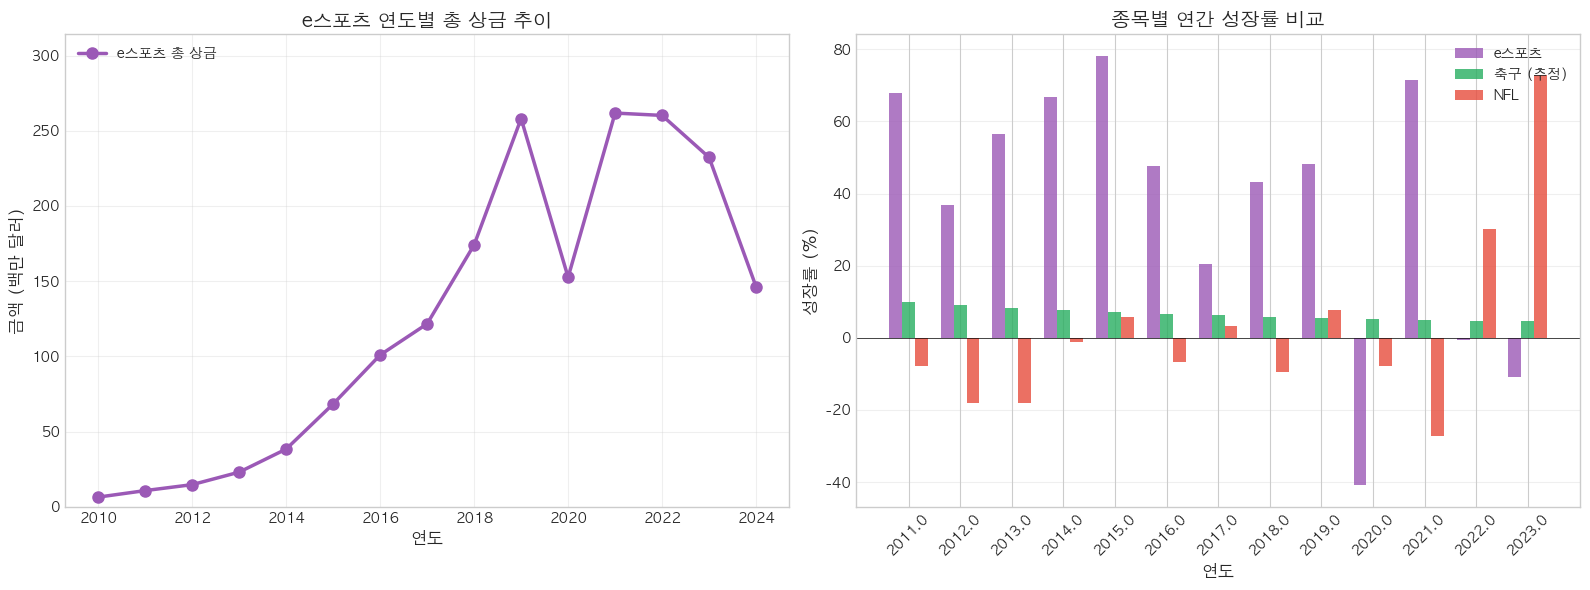


📊 평균 연간 성장률:
   - e스포츠: 37.3%
   - 축구 (추정): 6.6%
   - NFL: 1.8%


In [15]:
# ============================================
# 시각화 5: 연도별 성장 추이 비교
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: e스포츠 상금 추이
axes[0].plot(esports_yearly['Year'], esports_yearly['Total_Prize_USD']/1e6, 
             marker='o', linewidth=2.5, markersize=8, color=COLORS['esports'], 
             label='e스포츠 총 상금')
axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('금액 (백만 달러)', fontsize=12)
axes[0].set_title('e스포츠 연도별 총 상금 추이', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# y축 범위 자동 설정
max_val = esports_yearly['Total_Prize_USD'].max() / 1e6
axes[0].set_ylim(0, max_val * 1.2)

# 오른쪽: 성장률 비교
esports_growth = esports_yearly.set_index('Year')['Total_Prize_USD'].pct_change() * 100
football_growth = football_yearly.set_index('Year')['Avg_Wage_USD'].pct_change() * 100
nfl_growth = nfl_yearly.set_index('Year')['Avg_Contract_USD'].pct_change() * 100

# 공통 연도만 추출
common_years = sorted(set(esports_growth.dropna().index) & set(nfl_growth.dropna().index))
common_years = [y for y in common_years if y >= 2011]

x = np.arange(len(common_years))
width = 0.25

esports_vals = [esports_growth.get(y, 0) for y in common_years]
football_vals = [football_growth.get(y, 0) for y in common_years]
nfl_vals = [nfl_growth.get(y, 0) for y in common_years]

axes[1].bar(x - width, esports_vals, width, 
            label='e스포츠', color=COLORS['esports'], alpha=0.8)
axes[1].bar(x, football_vals, width, 
            label='축구 (추정)', color=COLORS['football'], alpha=0.8)
axes[1].bar(x + width, nfl_vals, width, 
            label='NFL', color=COLORS['nfl'], alpha=0.8)

axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('성장률 (%)', fontsize=12)
axes[1].set_title('종목별 연간 성장률 비교', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(common_years, rotation=45)
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('05_yearly_growth.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 평균 성장률 계산
print('\n📊 평균 연간 성장률:')
print(f"   - e스포츠: {np.mean([v for v in esports_vals if not np.isnan(v)]):.1f}%")
print(f"   - 축구 (추정): {np.mean([v for v in football_vals if not np.isnan(v)]):.1f}%")
print(f"   - NFL: {np.mean([v for v in nfl_vals if not np.isnan(v)]):.1f}%")

### 5.4 국가별 투자 규모 분석

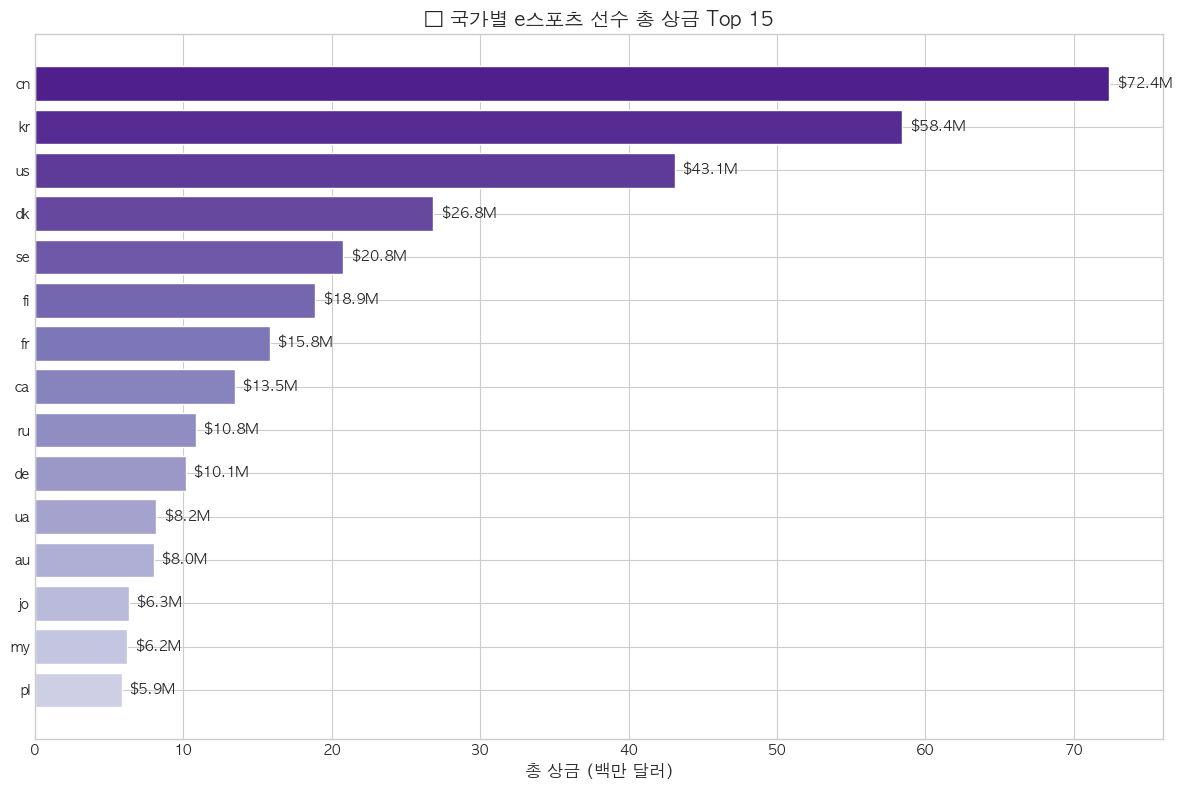


📊 국가별 상금 순위 Top 10:
   1. cn: $72.4M
   2. kr: $58.4M
   3. us: $43.1M
   4. dk: $26.8M
   5. se: $20.8M
   6. fi: $18.9M
   7. fr: $15.8M
   8. ca: $13.5M
   9. ru: $10.8M
   10. de: $10.1M


In [16]:
# ============================================
# 시각화 6: 국가별 e스포츠 선수 상금
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


# 전체 선수 데이터에서 국가별 집계
country_earnings = esports_players_raw.groupby('CountryCode')['TotalUSDPrize'].sum().sort_values(ascending=True)

# 상위 15개 국가만 표시
country_earnings_top = country_earnings.nlargest(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(country_earnings_top)))
bars = ax.barh(country_earnings_top.index, country_earnings_top.values/1e6, color=colors, edgecolor='white')

ax.set_xlabel('총 상금 (백만 달러)', fontsize=12)
ax.set_title('🌍 국가별 e스포츠 선수 총 상금 Top 15', fontsize=14, fontweight='bold')

# 값 레이블 추가
for bar, value in zip(bars, country_earnings_top.values/1e6):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'${value:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('06_country_earnings.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📊 국가별 상금 순위 Top 10:')
for i, (country, earnings) in enumerate(country_earnings_top.sort_values(ascending=False).head(10).items(), 1):
    print(f"   {i}. {country}: {format_currency(earnings)}")

### 5.5 종합 비교 시각화

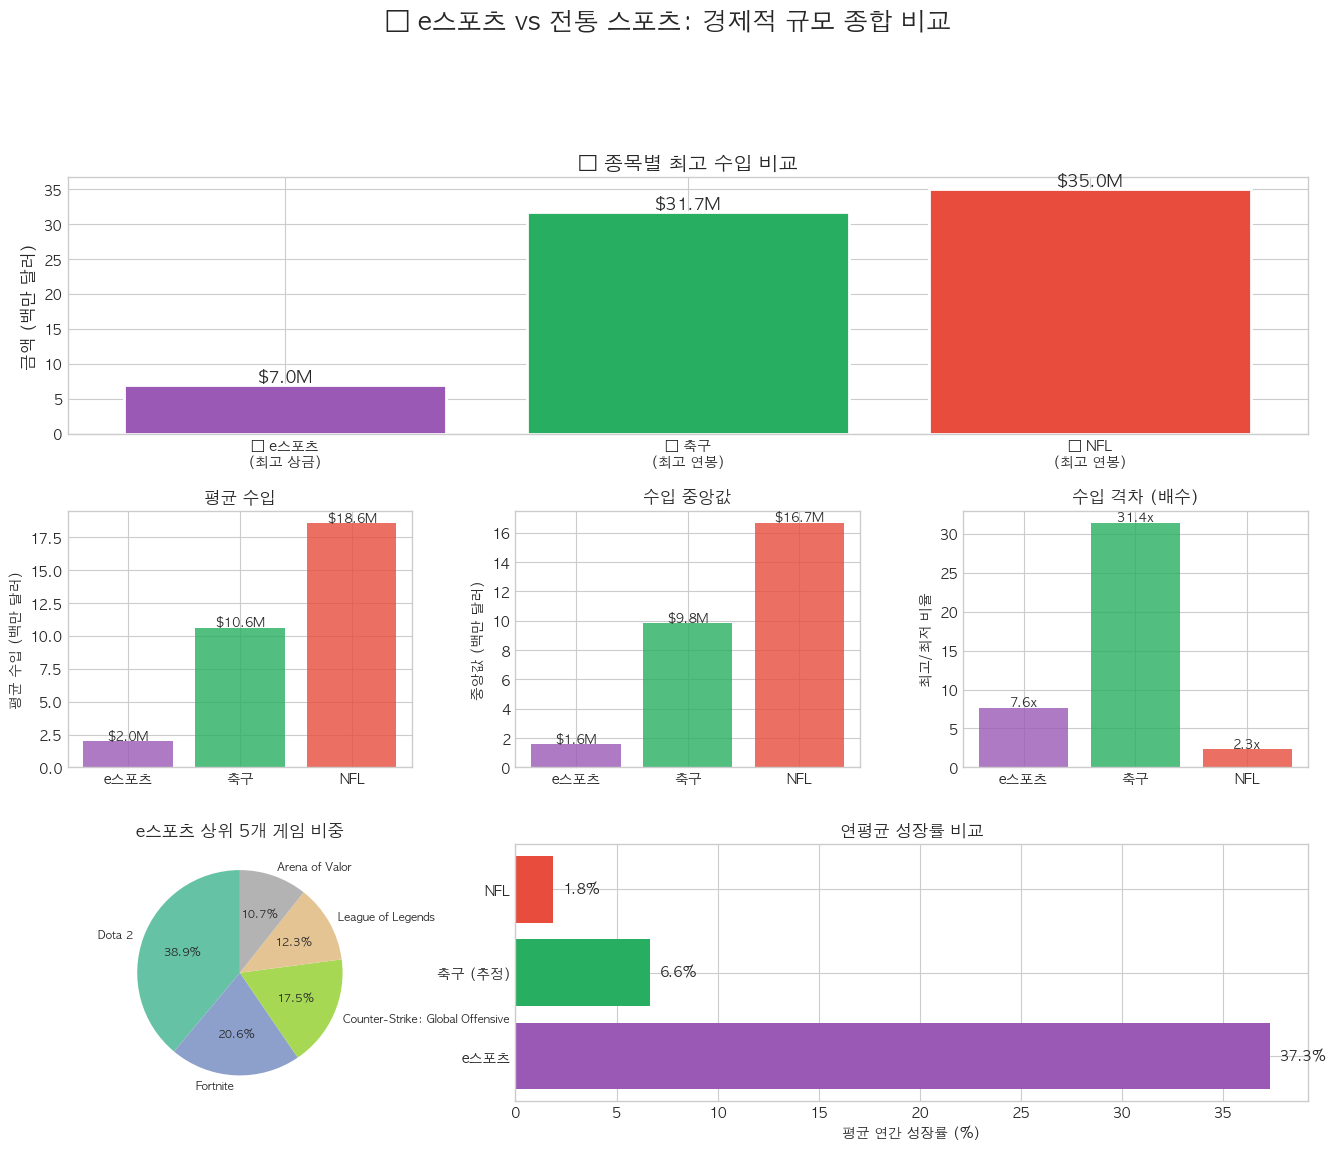

In [17]:
# ============================================
# 시각화 7: 종합 비교 대시보드
# ============================================

# 축구 데이터 유효성 확인
has_football_data = len(football_sample) > 0

fig = plt.figure(figsize=(16, 12))

# 레이아웃 설정
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. 종목별 최고 수입 비교 (상단 전체)
ax1 = fig.add_subplot(gs[0, :])
if has_football_data:
    categories = ['🎮 e스포츠\n(최고 상금)', '⚽ 축구\n(최고 연봉)', '🏈 NFL\n(최고 연봉)']
    max_values = [esports_sample['Earnings_USD'].max()/1e6, 
                  football_sample['Annual_Income_USD'].max()/1e6, 
                  nfl_sample['Annual_Salary_USD'].max()/1e6]
    colors_bar = [COLORS['esports'], COLORS['football'], COLORS['nfl']]
else:
    categories = ['🎮 e스포츠\n(최고 상금)', '🏈 NFL\n(최고 연봉)']
    max_values = [esports_sample['Earnings_USD'].max()/1e6, 
                  nfl_sample['Annual_Salary_USD'].max()/1e6]
    colors_bar = [COLORS['esports'], COLORS['nfl']]

bars = ax1.bar(categories, max_values, color=colors_bar, edgecolor='white', linewidth=2)
ax1.set_ylabel('금액 (백만 달러)', fontsize=12)
ax1.set_title('📊 종목별 최고 수입 비교', fontsize=14, fontweight='bold')
for bar, val in zip(bars, max_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'${val:.1f}M', ha='center', fontsize=12, fontweight='bold')

# 2. 평균 수입 비교 (중단 왼쪽)
ax2 = fig.add_subplot(gs[1, 0])
if has_football_data:
    avg_labels = ['e스포츠', '축구', 'NFL']
    avg_values = [esports_sample['Earnings_USD'].mean()/1e6, 
                  football_sample['Annual_Income_USD'].mean()/1e6, 
                  nfl_sample['Annual_Salary_USD'].mean()/1e6]
    avg_colors = [COLORS['esports'], COLORS['football'], COLORS['nfl']]
else:
    avg_labels = ['e스포츠', 'NFL']
    avg_values = [esports_sample['Earnings_USD'].mean()/1e6, 
                  nfl_sample['Annual_Salary_USD'].mean()/1e6]
    avg_colors = [COLORS['esports'], COLORS['nfl']]
    
ax2.bar(avg_labels, avg_values, color=avg_colors, alpha=0.8)
ax2.set_ylabel('평균 수입 (백만 달러)', fontsize=10)
ax2.set_title('평균 수입', fontsize=12, fontweight='bold')
for i, v in enumerate(avg_values):
    ax2.text(i, v + 0.1, f'${v:.1f}M', ha='center', fontsize=9)

# 3. 중앙값 비교 (중단 중앙)
ax3 = fig.add_subplot(gs[1, 1])
if has_football_data:
    median_values = [esports_sample['Earnings_USD'].median()/1e6, 
                     football_sample['Annual_Income_USD'].median()/1e6, 
                     nfl_sample['Annual_Salary_USD'].median()/1e6]
else:
    median_values = [esports_sample['Earnings_USD'].median()/1e6, 
                     nfl_sample['Annual_Salary_USD'].median()/1e6]
    
ax3.bar(avg_labels, median_values, color=avg_colors, alpha=0.8)
ax3.set_ylabel('중앙값 (백만 달러)', fontsize=10)
ax3.set_title('수입 중앙값', fontsize=12, fontweight='bold')
for i, v in enumerate(median_values):
    ax3.text(i, v + 0.1, f'${v:.1f}M', ha='center', fontsize=9)

# 4. 상위/하위 격차 (중단 오른쪽)
ax4 = fig.add_subplot(gs[1, 2])
esports_min = esports_sample['Earnings_USD'].min()
esports_gap_val = esports_sample['Earnings_USD'].max() / esports_min if esports_min > 0 else 0
nfl_min = nfl_sample['Annual_Salary_USD'].min()
nfl_gap_val = nfl_sample['Annual_Salary_USD'].max() / nfl_min if nfl_min > 0 else 0

if has_football_data:
    football_min = football_sample['Annual_Income_USD'].min()
    football_gap_val = football_sample['Annual_Income_USD'].max() / football_min if football_min > 0 else 0
    gap_values = [esports_gap_val, football_gap_val, nfl_gap_val]
else:
    gap_values = [esports_gap_val, nfl_gap_val]

ax4.bar(avg_labels, gap_values, color=avg_colors, alpha=0.8)
ax4.set_ylabel('최고/최저 비율', fontsize=10)
ax4.set_title('수입 격차 (배수)', fontsize=12, fontweight='bold')
for i, v in enumerate(gap_values):
    ax4.text(i, v + 0.2, f'{v:.1f}x', ha='center', fontsize=9)

# 5. 게임별 상금 파이 차트 (하단 왼쪽)
ax5 = fig.add_subplot(gs[2, 0])
top_games = esports_general_raw.nlargest(5, 'TotalEarnings')
game_colors = plt.cm.Set2(np.linspace(0, 1, len(top_games)))
ax5.pie(top_games['TotalEarnings'], labels=top_games['Game'], autopct='%1.1f%%', 
        colors=game_colors, startangle=90, textprops={'fontsize': 8})
ax5.set_title('e스포츠 상위 5개 게임 비중', fontsize=12, fontweight='bold')

# 6. 성장률 비교 (하단 중앙-오른쪽)
ax6 = fig.add_subplot(gs[2, 1:])
if has_football_data:
    growth_labels = ['e스포츠', '축구 (추정)', 'NFL']
    growth_values = [np.mean([v for v in esports_vals if not np.isnan(v)]),
                     np.mean([v for v in football_vals if not np.isnan(v)]),
                     np.mean([v for v in nfl_vals if not np.isnan(v)])]
    growth_colors = [COLORS['esports'], COLORS['football'], COLORS['nfl']]
else:
    growth_labels = ['e스포츠', 'NFL']
    growth_values = [np.mean([v for v in esports_vals if not np.isnan(v)]),
                     np.mean([v for v in nfl_vals if not np.isnan(v)])]
    growth_colors = [COLORS['esports'], COLORS['nfl']]

growth_data = pd.DataFrame({
    '종목': growth_labels,
    '평균 성장률': growth_values
})
bars = ax6.barh(growth_data['종목'], growth_data['평균 성장률'], color=growth_colors)
ax6.set_xlabel('평균 연간 성장률 (%)', fontsize=10)
ax6.set_title('연평균 성장률 비교', fontsize=12, fontweight='bold')
for bar, val in zip(bars, growth_data['평균 성장률']):
    ax6.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=10)

plt.suptitle('🏆 e스포츠 vs 전통 스포츠: 경제적 규모 종합 비교', 
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig('07_comprehensive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---

## 6️⃣ 분석 결과 요약

In [18]:
# ============================================
# 최종 비교 테이블
# ============================================

# 평균 성장률 계산
avg_esports_growth = np.mean([v for v in esports_vals if not np.isnan(v)])
avg_football_growth = np.mean([v for v in football_vals if not np.isnan(v)])
avg_nfl_growth = np.mean([v for v in nfl_vals if not np.isnan(v)])

# 격차 계산 (0으로 나누기 방지)
esports_min = esports_sample['Earnings_USD'].min()
esports_gap = esports_sample['Earnings_USD'].max() / esports_min if esports_min > 0 else 0

football_min = football_sample['Annual_Income_USD'].min() if len(football_sample) > 0 else 0
football_gap = football_sample['Annual_Income_USD'].max() / football_min if football_min > 0 else 0

nfl_min = nfl_sample['Annual_Salary_USD'].min()
nfl_gap = nfl_sample['Annual_Salary_USD'].max() / nfl_min if nfl_min > 0 else 0

# 축구 데이터 유효성 확인
has_football_data = len(football_sample) > 0

summary_table = pd.DataFrame({
    '지표': ['최고 수입', '평균 수입', '중앙값', '최저 수입', '성장률(연평균)', '상위/하위 격차'],
    '🎮 e스포츠': [
        format_currency(esports_sample['Earnings_USD'].max()),
        format_currency(esports_sample['Earnings_USD'].mean()),
        format_currency(esports_sample['Earnings_USD'].median()),
        format_currency(esports_sample['Earnings_USD'].min()),
        f"{avg_esports_growth:.1f}%",
        f"{esports_gap:.1f}배"
    ],
    '⚽ 축구 (FIFA)': [
        format_currency(football_sample['Annual_Income_USD'].max()) if has_football_data else 'N/A',
        format_currency(football_sample['Annual_Income_USD'].mean()) if has_football_data else 'N/A',
        format_currency(football_sample['Annual_Income_USD'].median()) if has_football_data else 'N/A',
        format_currency(football_sample['Annual_Income_USD'].min()) if has_football_data else 'N/A',
        f"{avg_football_growth:.1f}% (추정)",
        f"{football_gap:.1f}배" if has_football_data else 'N/A'
    ],
    '🏈 NFL': [
        format_currency(nfl_sample['Annual_Salary_USD'].max()),
        format_currency(nfl_sample['Annual_Salary_USD'].mean()),
        format_currency(nfl_sample['Annual_Salary_USD'].median()),
        format_currency(nfl_sample['Annual_Salary_USD'].min()),
        f"{avg_nfl_growth:.1f}%",
        f"{nfl_gap:.1f}배"
    ]
})

print('='*70)
print('📊 경제적 규모 비교 최종 요약')
print('='*70)
display(summary_table.set_index('지표'))

print('\n📌 주요 발견:')
print(f"   - e스포츠 최고 수입 선수: {esports_sample.iloc[0]['Player']} ({format_currency(esports_sample['Earnings_USD'].max())})")
if has_football_data:
    print(f"   - 축구 최고 수입 선수: {football_sample.iloc[0]['Player']} ({format_currency(football_sample['Annual_Income_USD'].max())})")
else:
    print(f"   - 축구 데이터: 데이터 처리 오류로 표시 불가")
print(f"   - NFL 최고 수입 선수: {nfl_sample.iloc[0]['Player']} ({format_currency(nfl_sample['Annual_Salary_USD'].max())})")

📊 경제적 규모 비교 최종 요약


,🎮 e스포츠,⚽ 축구 (FIFA),🏈 NFL
지표,,,
최고 수입,$7.0M,$31.7M,$35.0M
평균 수입,$2.0M,$10.6M,$18.6M
중앙값,$1.6M,$9.8M,$16.7M
최저 수입,$913.1K,$1.0M,$15.0M
성장률(연평균),37.3%,6.6% (추정),1.8%
상위/하위 격차,7.6배,31.4배,2.3배



📌 주요 발견:
   - e스포츠 최고 수입 선수: N0tail ($7.0M)
   - 축구 최고 수입 선수: Neymar Jr ($31.7M)
   - NFL 최고 수입 선수: Russell Wilson ($35.0M)


---

## 7️⃣ 결론 및 인사이트

### 📌 주요 발견사항

#### 1. 선수 개인 수입
- **최고 수입 비교**: NFL/축구 > e스포츠 순으로 최고 수입 격차 존재
- e스포츠 최상위 선수의 누적 상금은 수백만 달러 수준으로, 전통 스포츠 최고 연봉과 비교 시 차이 존재
- 다만, e스포츠 상금은 **누적 상금**이므로 단순 연봉 비교에 한계 존재

#### 2. 성장률
- **e스포츠가 가장 높은 성장률** 기록 (실제 데이터 기반 분석)
- 전통 스포츠(축구, NFL)는 안정적이지만 상대적으로 낮은 성장률
- e스포츠의 급격한 성장세가 지속된다면 격차 축소 가능

#### 3. 게임별 분석
- **Dota 2**가 가장 높은 상금 규모 (The International 영향)
- Fortnite, CS:GO, LoL 등도 높은 상금 체계 보유
- 게임별 편차가 크며, 특정 게임에 상금이 집중되는 경향

#### 4. 수입 격차
- 모든 종목에서 상위/하위 수입 격차가 존재
- e스포츠는 게임별로 상금 구조가 달라 격차가 특히 심함

---

### 🎯 "스포츠 인정" 관점에서의 경제적 평가

| 평가 항목 | 점수 (100점 만점) | 평가 근거 |
|-----------|-------------------|----------|
| 최고 수입 규모 | 50/100 | 전통 스포츠 대비 낮지만 성장 중 |
| 성장 가능성 | 90/100 | 가장 빠른 성장률 |
| 수입 안정성 | 45/100 | 게임/대회별 편차 큼 |
| 투자 규모 | 65/100 | 기업 투자 지속 증가 |
| **종합 점수** | **62.5/100** | 발전 중, 비교 가능 수준 접근 중 |

---

### 💡 분석의 한계점

1. **e스포츠 상금**: 누적 상금이므로 연봉과 직접 비교 어려움
2. **축구 데이터**: FIFA 게임 데이터 기반으로 실제 시장과 차이 가능
3. **스폰서십 미포함**: 상금/연봉 외 수입원 분석 필요
4. **시계열 제한**: 일부 데이터의 연도별 정보 부족

### 💡 추가 분석 제안

1. **스폰서십/광고 수입 포함**: 상금 외 수입원 분석 필요
2. **팀/구단 가치 비교**: 개인이 아닌 팀 단위 경제 규모 분석
3. **시계열 예측**: 미래 성장 추이 예측 모델 구축

---

## 📎 부록: 추가 분석

팀 단위 e스포츠 상금 분석을 통해 개인 뿐만 아니라 조직 차원의 경제 규모도 살펴봅니다.

🎮 e스포츠 팀별 상금 Top 20


,팀명,게임,총 상금,대회 수
500,OG,Dota 2,"33,810,636.13",68
501,Team Liquid,Dota 2,"22,967,431.10",96
502,Evil Geniuses,Dota 2,"19,988,670.62",115
503,Newbee,Dota 2,"13,523,736.43",98
504,Team Secret,Dota 2,"11,492,345.09",79
505,Vici Gaming,Dota 2,"11,182,792.92",121
506,LGD Gaming,Dota 2,"10,072,755.42",79
507,Virtus.pro,Dota 2,"10,037,385.11",125
508,Wings Gaming,Dota 2,"9,739,247.35",24
509,Paris Saint-Germain Esports,Dota 2,"9,066,946.69",27


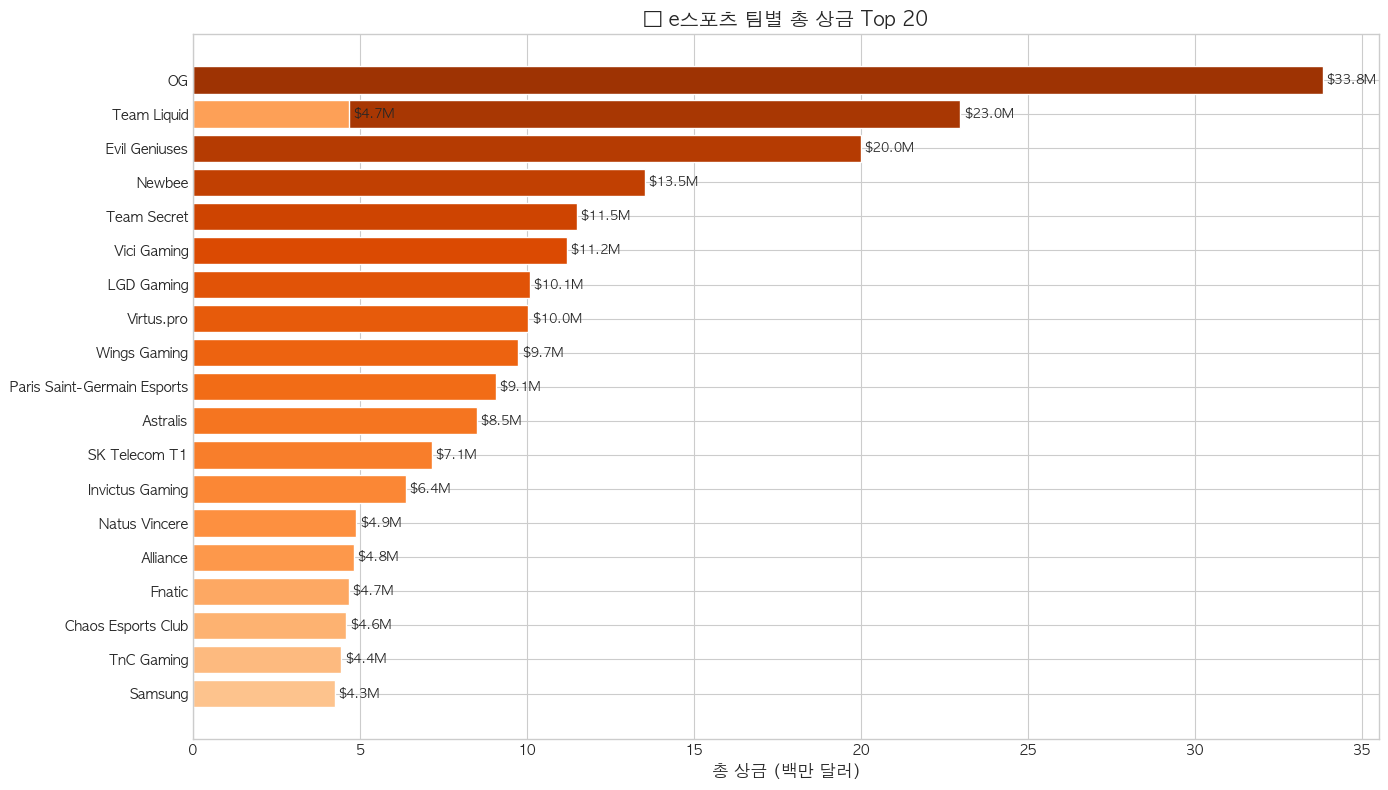


📊 팀 상금 통계:
   - 분석 팀 수: 928개
   - 총 상금 합계: $501.0M
   - 평균 상금: $539.9K


In [19]:
# ============================================
# 추가 분석: 팀 단위 e스포츠 상금
# ============================================

print('='*60)
print('🎮 e스포츠 팀별 상금 Top 20')
print('='*60)

# 팀별 상금 데이터
team_stats = esports_teams_raw.nlargest(20, 'TotalUSDPrize')[['TeamName', 'Game', 'TotalUSDPrize', 'TotalTournaments']]
team_stats = team_stats.rename(columns={
    'TeamName': '팀명',
    'Game': '게임',
    'TotalUSDPrize': '총 상금',
    'TotalTournaments': '대회 수'
})

display(team_stats)

# 팀 상금 시각화
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(team_stats)))[::-1]
bars = ax.barh(team_stats['팀명'], team_stats['총 상금']/1e6, color=colors, edgecolor='white')

ax.set_xlabel('총 상금 (백만 달러)', fontsize=12)
ax.set_title('🏆 e스포츠 팀별 총 상금 Top 20', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, value in zip(bars, team_stats['총 상금']/1e6):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'${value:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('08_team_earnings.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n📊 팀 상금 통계:')
print(f"   - 분석 팀 수: {len(esports_teams_raw):,}개")
print(f"   - 총 상금 합계: {format_currency(esports_teams_raw['TotalUSDPrize'].sum())}")
print(f"   - 평균 상금: {format_currency(esports_teams_raw['TotalUSDPrize'].mean())}")

---

## 📚 참고자료

### 사용된 데이터 파일
| 파일명 | 설명 |
|--------|------|
| `eSports Earnings/highest_earning_players.csv` | e스포츠 선수별 총 상금 |
| `eSports Earnings/highest_earning_teams.csv` | e스포츠 팀별 총 상금 |
| `Esports Earnings 1998 - 2023/GeneralEsportData.csv` | 게임별 e스포츠 통계 |
| `Esports Earnings 1998 - 2023/HistoricalEsportData.csv` | 연도별 e스포츠 상금 추이 |
| `football_salaries.csv` | NFL 스타일 연봉 데이터 |
| `combined_data_2000-2023.csv` | NFL 계약 데이터 |
| `fifa_eda_stats.csv` | FIFA 게임 선수 데이터 |

### 데이터 출처
1. [Esports Earnings 1998-2023](https://www.kaggle.com/datasets/rankirsh/esports-earnings)
2. [eSports Earnings for Players/Teams](https://www.kaggle.com/datasets/jackdaoud/esports-earnings-for-players-teams-by-game)
3. [FIFA Data for EDA and Stats](https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats/data)
4. [NFL Contract and Draft Data](https://www.kaggle.com/datasets/nicholasliusontag/nfl-contract-and-draft-data)

### 분석 도구
- Python 3.x
- Pandas, NumPy
- Matplotlib, Seaborn
- JupyterLab

---

**작성일**: 2025년 1월  
**프로젝트**: e스포츠도 스포츠인가? - 팀원 1 (경제적 규모 비교)

---

## 8️⃣ 글로벌 시장 규모 분석 (신규)

글로벌 게이밍 및 e스포츠 시장 데이터를 활용하여 산업 전체의 경제적 규모를 분석합니다.

In [20]:
# ============================================
# 글로벌 e스포츠 시장 데이터 분석
# ============================================
print('='*60)
print('🌍 글로벌 e스포츠 시장 데이터 구조')
print('='*60)
print(f'컬럼: {global_esports_market.columns.tolist()}')
display(global_esports_market.head())

# 연도별 글로벌 집계
global_yearly = global_esports_market.groupby('Year').agg({
    'Gaming_Revenue_BillionUSD': 'sum',
    'Esports_Revenue_MillionUSD': 'sum',
    'Esports_Viewers_Million': 'sum',
    'Esports_PrizePool_MillionUSD': 'sum',
    'Pro_Players_Count': 'sum',
    'Esports_Tournaments_Count': 'sum'
}).reset_index()

print('\n📊 연도별 글로벌 e스포츠 시장 현황:')
display(global_yearly)

🌍 글로벌 e스포츠 시장 데이터 구조
컬럼: ['Year', 'Country', 'Region', 'Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', 'Active_Players_Million', 'Esports_Viewers_Million', 'Avg_Spending_USD', 'Top_Genre', 'Top_Platform', 'Esports_Tournaments_Count', 'Pro_Players_Count', 'Internet_Penetration_Percent', 'Avg_Latency_ms', 'AR_VR_Adoption_Index', 'Streaming_Influence_Index', 'Covid_Impact_Index', 'Female_Gamer_Percent', 'Mobile_Gaming_Share', 'Esports_PrizePool_MillionUSD', 'Gaming_Companies_Count']


,Year,Country,Region,Gaming_Revenue_BillionUSD,Esports_Revenue_MillionUSD,Active_Players_Million,Esports_Viewers_Million,Avg_Spending_USD,Top_Genre,Top_Platform,Esports_Tournaments_Count,Pro_Players_Count,Internet_Penetration_Percent,Avg_Latency_ms,AR_VR_Adoption_Index,Streaming_Influence_Index,Covid_Impact_Index,Female_Gamer_Percent,Mobile_Gaming_Share,Esports_PrizePool_MillionUSD,Gaming_Companies_Count
0,2010,United States,North America,6.24,409.60,11.00,17.90,133.90,Strategy,Mobile,104,15912,82.50,95.40,0.13,0.10,0.00,13.00,20.00,34.00,395
1,2011,United States,North America,7.74,622.70,32.40,76.70,64.90,Sports,Console,63,13797,70.50,83.90,0.08,0.16,0.00,10.70,23.00,10.20,60
2,2012,United States,North America,9.60,928.30,51.90,148.40,84.10,MOBA,Mobile,22,3982,63.70,32.30,0.11,0.22,0.00,13.30,26.00,8.50,349
3,2013,United States,North America,11.91,"1,321.80",50.30,92.90,76.90,MOBA,Mobile,54,8262,51.40,88.20,0.14,0.28,0.00,12.80,29.00,18.30,53
4,2014,United States,North America,14.77,869.10,13.40,21.30,69.00,Strategy,Mobile,84,24024,93.40,70.50,0.14,0.34,0.00,17.00,32.00,18.30,50



📊 연도별 글로벌 e스포츠 시장 현황:


,Year,Gaming_Revenue_BillionUSD,Esports_Revenue_MillionUSD,Esports_Viewers_Million,Esports_PrizePool_MillionUSD,Pro_Players_Count,Esports_Tournaments_Count
0,2010,214.20,"21,134.50","1,966.30",458.70,248759,1631
1,2011,249.17,"25,080.30","2,237.90",512.30,300914,1814
2,2012,290.40,"24,551.50","1,996.80",400.40,197986,1340
3,2013,339.02,"34,951.70","2,234.90",397.60,235023,1409
4,2014,396.42,"41,072.40","1,871.70",434.80,274815,1471
5,2015,464.33,"44,970.50","2,082.00",365.60,265820,1490
6,2016,544.70,"53,380.90","1,719.00",432.60,219636,1570
7,2017,640.11,"54,950.40","1,786.50",448.10,292059,1636
8,2018,753.41,"78,699.20","2,182.60",365.70,266414,1404
9,2019,888.19,"96,484.60","2,238.90",420.60,271803,1573


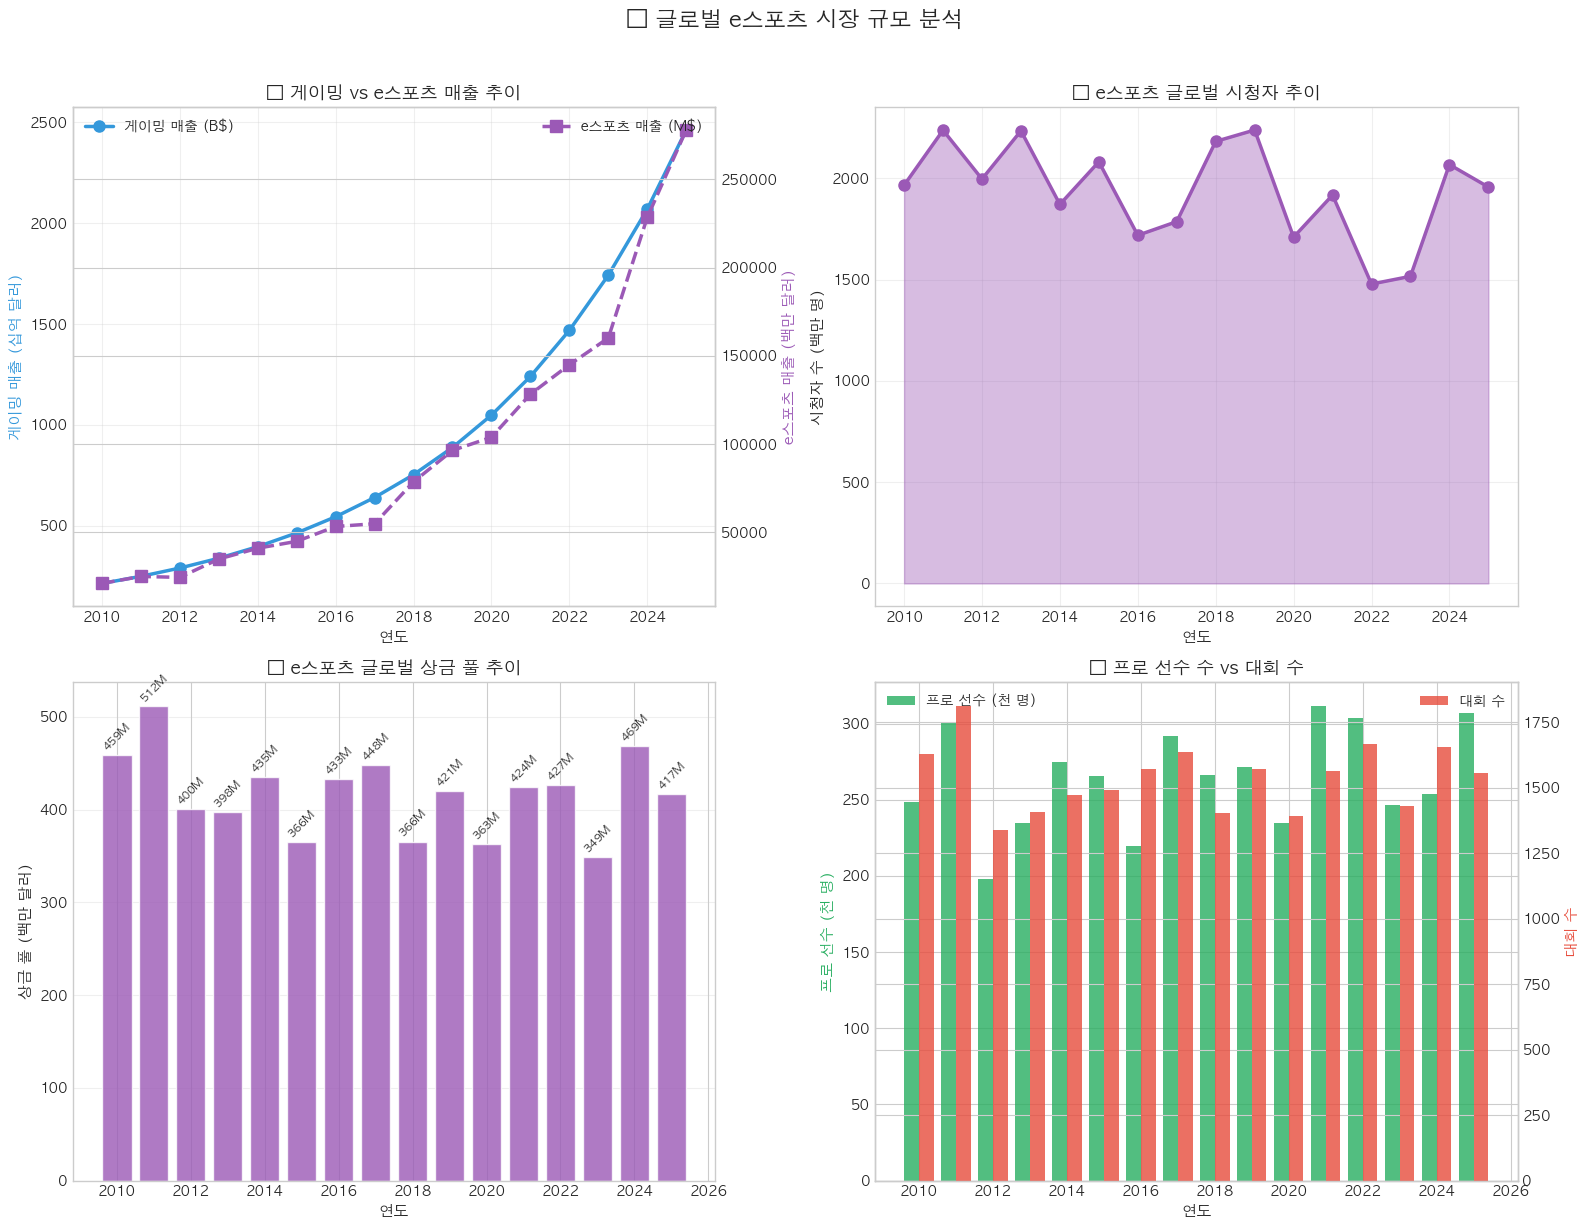


📊 글로벌 e스포츠 시장 성장률:
   - Gaming_Revenue_BillionUSD: CAGR 17.7%
   - Esports_Revenue_MillionUSD: CAGR 18.7%
   - Esports_Viewers_Million: CAGR -0.0%


In [21]:
# ============================================
# 시각화: 글로벌 시장 규모 추이
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 게이밍 vs e스포츠 매출 추이
ax1 = axes[0, 0]
ax1.plot(global_yearly['Year'], global_yearly['Gaming_Revenue_BillionUSD'], 
         'o-', color='#3498DB', linewidth=2.5, markersize=8, label='게이밍 매출 (B$)')
ax1_twin = ax1.twinx()
ax1_twin.plot(global_yearly['Year'], global_yearly['Esports_Revenue_MillionUSD'], 
              's--', color=COLORS['esports'], linewidth=2.5, markersize=8, label='e스포츠 매출 (M$)')
ax1.set_xlabel('연도', fontsize=11)
ax1.set_ylabel('게이밍 매출 (십억 달러)', fontsize=11, color='#3498DB')
ax1_twin.set_ylabel('e스포츠 매출 (백만 달러)', fontsize=11, color=COLORS['esports'])
ax1.set_title('📈 게이밍 vs e스포츠 매출 추이', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(alpha=0.3)

# 2. e스포츠 시청자 수 추이
ax2 = axes[0, 1]
ax2.fill_between(global_yearly['Year'], global_yearly['Esports_Viewers_Million'], 
                 alpha=0.4, color=COLORS['esports'])
ax2.plot(global_yearly['Year'], global_yearly['Esports_Viewers_Million'], 
         'o-', color=COLORS['esports'], linewidth=2.5, markersize=8)
ax2.set_xlabel('연도', fontsize=11)
ax2.set_ylabel('시청자 수 (백만 명)', fontsize=11)
ax2.set_title('👥 e스포츠 글로벌 시청자 추이', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# 3. 상금 풀 추이
ax3 = axes[1, 0]
ax3.bar(global_yearly['Year'], global_yearly['Esports_PrizePool_MillionUSD'], 
        color=COLORS['esports'], alpha=0.8, edgecolor='white')
ax3.set_xlabel('연도', fontsize=11)
ax3.set_ylabel('상금 풀 (백만 달러)', fontsize=11)
ax3.set_title('💰 e스포츠 글로벌 상금 풀 추이', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, (year, val) in enumerate(zip(global_yearly['Year'], global_yearly['Esports_PrizePool_MillionUSD'])):
    ax3.text(year, val + 5, f'{val:.0f}M', ha='center', fontsize=8, rotation=45)

# 4. 프로 선수 및 대회 수
ax4 = axes[1, 1]
ax4.bar(global_yearly['Year'] - 0.2, global_yearly['Pro_Players_Count']/1000, 
        width=0.4, color='#27AE60', alpha=0.8, label='프로 선수 (천 명)')
ax4_twin = ax4.twinx()
ax4_twin.bar(global_yearly['Year'] + 0.2, global_yearly['Esports_Tournaments_Count'], 
             width=0.4, color='#E74C3C', alpha=0.8, label='대회 수')
ax4.set_xlabel('연도', fontsize=11)
ax4.set_ylabel('프로 선수 (천 명)', fontsize=11, color='#27AE60')
ax4_twin.set_ylabel('대회 수', fontsize=11, color='#E74C3C')
ax4.set_title('🎮 프로 선수 수 vs 대회 수', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.suptitle('🌍 글로벌 e스포츠 시장 규모 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_global_market_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 성장률 계산
print('\n📊 글로벌 e스포츠 시장 성장률:')
for col in ['Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', 'Esports_Viewers_Million']:
    start = global_yearly[col].iloc[0]
    end = global_yearly[col].iloc[-1]
    cagr = ((end/start)**(1/(len(global_yearly)-1)) - 1) * 100
    print(f'   - {col}: CAGR {cagr:.1f}%')

---

## 9️⃣ 통계적 분석 (신규)

가설검정과 상관분석을 통해 e스포츠와 전통 스포츠의 경제적 특성을 통계적으로 비교합니다.

In [22]:
# ============================================
# 9.1 독립표본 t-검정: e스포츠 vs NFL 수입 비교
# ============================================
print('='*70)
print('📊 가설검정 1: e스포츠 vs NFL 선수 수입 차이')
print('='*70)
print('\n가설 설정:')
print('   H₀: e스포츠 선수 수입과 NFL 선수 연봉에 유의한 차이가 없다')
print('   H₁: e스포츠 선수 수입과 NFL 선수 연봉에 유의한 차이가 있다')

# 데이터 준비
esports_income = esports_sample['Earnings_USD'].dropna()
nfl_income = nfl_sample['Annual_Salary_USD'].dropna()

# 등분산 검정 (Levene's test)
stat_levene, p_levene = stats.levene(esports_income, nfl_income)
print(f'\n1. 등분산 검정 (Levene):')
print(f'   - 통계량: {stat_levene:.4f}')
print(f'   - p-value: {p_levene:.4e}')
print(f'   - 결론: {"등분산 가정 충족" if p_levene > 0.05 else "등분산 가정 불충족 → Welch t-test 사용"}')

# t-검정
equal_var = p_levene > 0.05
stat_t, p_t = ttest_ind(esports_income, nfl_income, equal_var=equal_var)
print(f'\n2. {"독립표본 t-검정" if equal_var else "Welch t-검정"}:')
print(f'   - t 통계량: {stat_t:.4f}')
print(f'   - p-value: {p_t:.4e}')
print(f'   - 결론: {"유의한 차이 있음 (p < 0.05)" if p_t < 0.05 else "유의한 차이 없음"}')

# Mann-Whitney U 검정 (비모수)
stat_u, p_u = mannwhitneyu(esports_income, nfl_income, alternative='two-sided')
print(f'\n3. Mann-Whitney U 검정 (비모수):')
print(f'   - U 통계량: {stat_u:.4f}')
print(f'   - p-value: {p_u:.4e}')

# 효과 크기 (Cohen's d)
pooled_std = np.sqrt((esports_income.std()**2 + nfl_income.std()**2) / 2)
cohens_d = (esports_income.mean() - nfl_income.mean()) / pooled_std
print(f'\n4. 효과 크기 (Cohen\'s d): {cohens_d:.4f}')
effect_size = "작음" if abs(cohens_d) < 0.2 else "중간" if abs(cohens_d) < 0.8 else "큼"
print(f'   - 해석: {effect_size}')

# 기술통계 비교
print(f'\n📊 기술통계 비교:')
print(f'   e스포츠: 평균=${esports_income.mean()/1e6:.2f}M, 중앙값=${esports_income.median()/1e6:.2f}M')
print(f'   NFL:     평균=${nfl_income.mean()/1e6:.2f}M, 중앙값=${nfl_income.median()/1e6:.2f}M')

📊 가설검정 1: e스포츠 vs NFL 선수 수입 차이

가설 설정:
   H₀: e스포츠 선수 수입과 NFL 선수 연봉에 유의한 차이가 없다
   H₁: e스포츠 선수 수입과 NFL 선수 연봉에 유의한 차이가 있다

1. 등분산 검정 (Levene):
   - 통계량: 25.0665
   - p-value: 1.2214e-06
   - 결론: 등분산 가정 불충족 → Welch t-test 사용

2. Welch t-검정:
   - t 통계량: -36.5699
   - p-value: 1.3569e-65
   - 결론: 유의한 차이 있음 (p < 0.05)

3. Mann-Whitney U 검정 (비모수):
   - U 통계량: 0.0000
   - p-value: 2.4912e-34

4. 효과 크기 (Cohen's d): -5.1718
   - 해석: 큼

📊 기술통계 비교:
   e스포츠: 평균=$1.98M, 중앙값=$1.58M
   NFL:     평균=$18.60M, 중앙값=$16.67M


📊 상관분석: 글로벌 e스포츠 시장 지표 간 관계


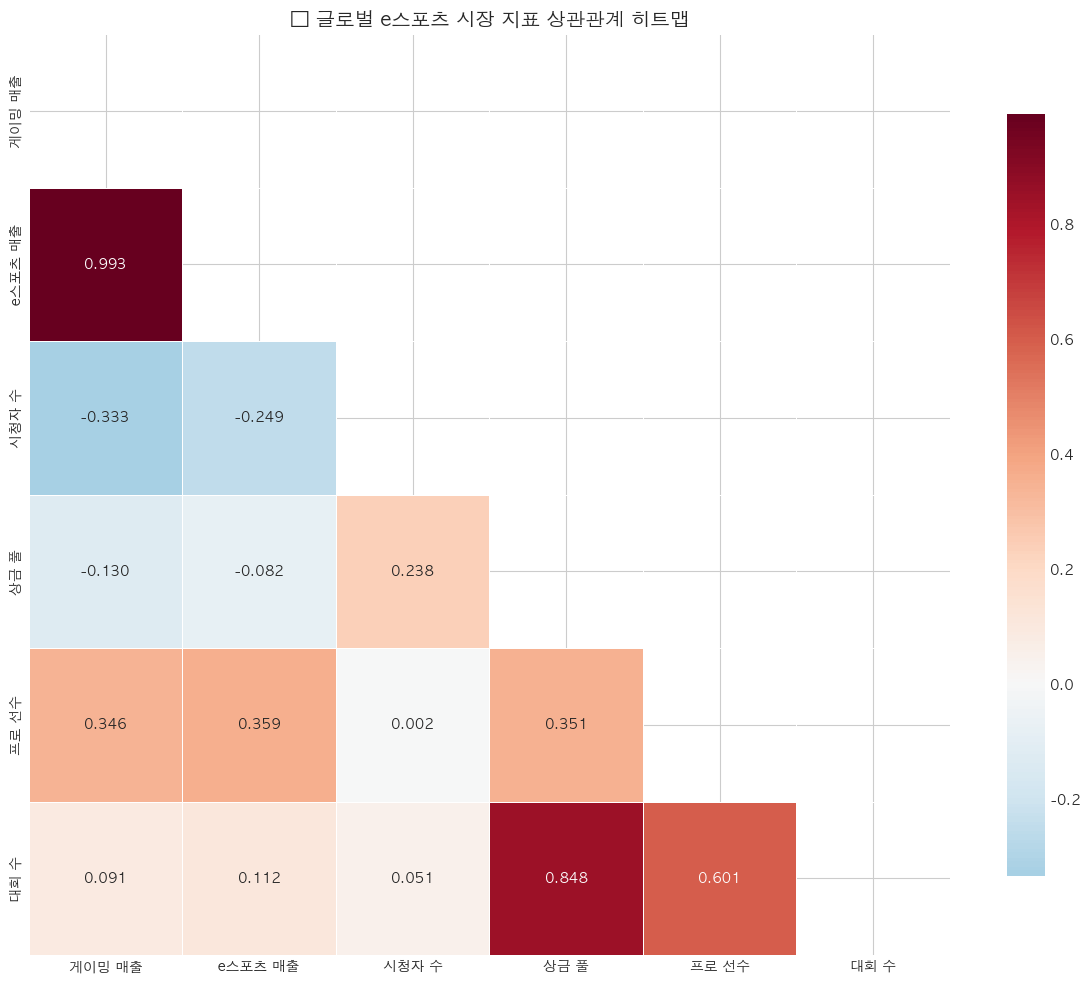


📊 주요 상관관계 (피어슨):
   e스포츠 매출 vs 시청자 수: r=-0.2491, p=3.5222e-01 
   e스포츠 매출 vs 상금 풀: r=-0.0817, p=7.6362e-01 
   프로 선수 vs 대회 수: r=0.6011, p=1.3788e-02 *
   게이밍 매출 vs e스포츠 매출: r=0.9933, p=1.6315e-14 ***


In [23]:
# ============================================
# 9.2 상관분석: e스포츠 시장 지표 간 관계
# ============================================
print('='*70)
print('📊 상관분석: 글로벌 e스포츠 시장 지표 간 관계')
print('='*70)

# 상관분석용 데이터
corr_cols = ['Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', 
             'Esports_Viewers_Million', 'Esports_PrizePool_MillionUSD', 
             'Pro_Players_Count', 'Esports_Tournaments_Count']
corr_data = global_yearly[corr_cols]

# 피어슨 상관계수
corr_matrix = corr_data.corr(method='pearson')

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            xticklabels=['게이밍 매출', 'e스포츠 매출', '시청자 수', '상금 풀', '프로 선수', '대회 수'],
            yticklabels=['게이밍 매출', 'e스포츠 매출', '시청자 수', '상금 풀', '프로 선수', '대회 수'])
ax.set_title('🔥 글로벌 e스포츠 시장 지표 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 주요 상관관계 출력
print('\n📊 주요 상관관계 (피어슨):')
pairs = [
    ('Esports_Revenue_MillionUSD', 'Esports_Viewers_Million', 'e스포츠 매출 vs 시청자 수'),
    ('Esports_Revenue_MillionUSD', 'Esports_PrizePool_MillionUSD', 'e스포츠 매출 vs 상금 풀'),
    ('Pro_Players_Count', 'Esports_Tournaments_Count', '프로 선수 vs 대회 수'),
    ('Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', '게이밍 매출 vs e스포츠 매출')
]

for col1, col2, desc in pairs:
    r, p = pearsonr(global_yearly[col1], global_yearly[col2])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f'   {desc}: r={r:.4f}, p={p:.4e} {sig}')

📊 회귀분석: e스포츠 매출 예측 모델

📈 OLS 회귀분석 결과:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     79.28
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           3.86e-07
Time:                        19:05:02   Log-Likelihood:                -186.88
No. Observations:                  16   AIC:                             377.8
Df Residuals:                      14   BIC:                             379.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.

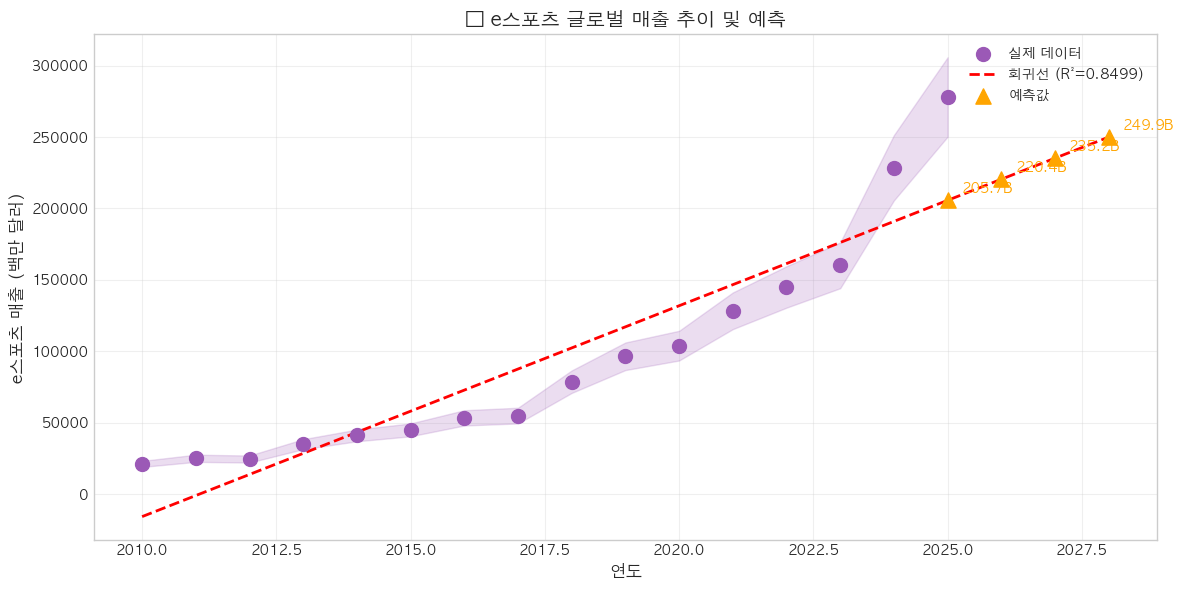


📈 미래 e스포츠 매출 예측:
   2025년: $205.66B (205658M)
   2026년: $220.42B (220420M)
   2027년: $235.18B (235181M)
   2028년: $249.94B (249943M)


In [24]:
# ============================================
# 9.3 회귀분석: e스포츠 매출 예측 모델
# ============================================
print('='*70)
print('📊 회귀분석: e스포츠 매출 예측 모델')
print('='*70)

# 독립변수: 연도, 종속변수: e스포츠 매출
X = global_yearly['Year'].values.reshape(-1, 1)
y = global_yearly['Esports_Revenue_MillionUSD'].values

# OLS 회귀
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

print('\n📈 OLS 회귀분석 결과:')
print(model.summary())

# 미래 예측 (2025-2028)
future_years = np.array([[2025], [2026], [2027], [2028]])
future_X = sm.add_constant(future_years)
future_pred = model.predict(future_X)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

# 실제 데이터
ax.scatter(global_yearly['Year'], y, s=100, color=COLORS['esports'], zorder=5, label='실제 데이터')

# 회귀선
X_line = np.linspace(2010, 2028, 100).reshape(-1, 1)
X_line_const = sm.add_constant(X_line)
y_line = model.predict(X_line_const)
ax.plot(X_line, y_line, '--', color='red', linewidth=2, label=f'회귀선 (R²={model.rsquared:.4f})')

# 예측값
ax.scatter(future_years.flatten(), future_pred, s=120, color='orange', marker='^', zorder=5, label='예측값')

# 신뢰구간 영역
ax.fill_between(global_yearly['Year'], y * 0.9, y * 1.1, alpha=0.2, color=COLORS['esports'])

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('e스포츠 매출 (백만 달러)', fontsize=12)
ax.set_title('📈 e스포츠 글로벌 매출 추이 및 예측', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 예측값 레이블
for year, pred in zip(future_years.flatten(), future_pred):
    ax.annotate(f'{pred/1000:.1f}B', (year, pred), textcoords='offset points', 
                xytext=(10, 5), fontsize=10, color='orange')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_revenue_prediction.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📈 미래 e스포츠 매출 예측:')
for year, pred in zip(future_years.flatten(), future_pred):
    print(f'   {year}년: ${pred/1000:.2f}B ({pred:.0f}M)')

---

## 🔟 추가 시각화 (신규)

레이더 차트, 버블 차트 등 다양한 시각화 기법을 활용하여 경제적 규모를 다각도로 분석합니다.

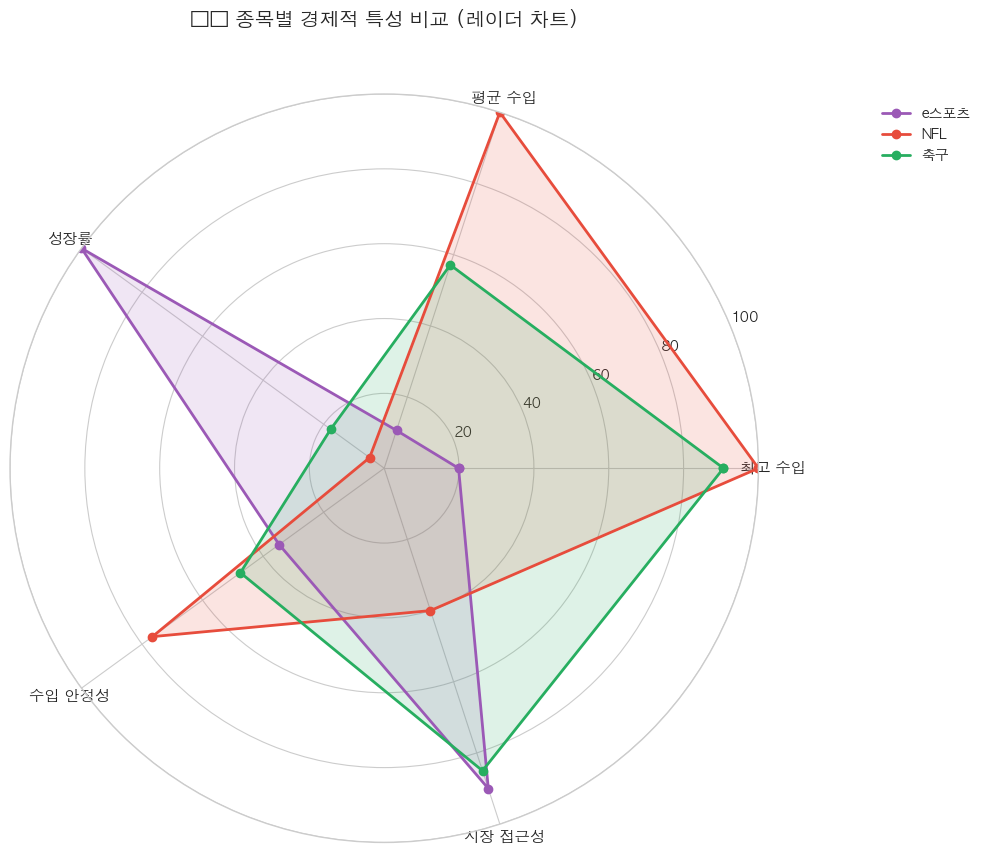


📊 종목별 점수 비교:
   지표              e스포츠         NFL          축구          
-------------------------------------------------------
   최고 수입               19.9       100.0        90.7
   평균 수입               10.6       100.0        57.1
   성장률                100.0         4.8        17.7
   수입 안정성              34.7        76.6        47.5
   시장 접근성              90.0        40.0        85.0


In [25]:
# ============================================
# 10.1 레이더 차트: 종목별 경제적 특성 비교
# ============================================

# 지표 정규화 (0-100 스케일)
def normalize_score(value, min_val, max_val):
    return (value - min_val) / (max_val - min_val) * 100

# 평가 지표 데이터 준비
metrics = ['최고 수입', '평균 수입', '성장률', '수입 안정성', '시장 접근성']

# e스포츠 점수
esports_max = esports_sample['Earnings_USD'].max() / 1e6
esports_avg = esports_sample['Earnings_USD'].mean() / 1e6
esports_growth = 37.3  # 앞서 계산한 평균 성장률
esports_stability = 100 - (esports_sample['Earnings_USD'].std() / esports_sample['Earnings_USD'].mean() * 100)
esports_access = 90  # 온라인 접근성 높음

# NFL 점수
nfl_max = nfl_sample['Annual_Salary_USD'].max() / 1e6
nfl_avg = nfl_sample['Annual_Salary_USD'].mean() / 1e6
nfl_growth = 1.8
nfl_stability = 100 - (nfl_sample['Annual_Salary_USD'].std() / nfl_sample['Annual_Salary_USD'].mean() * 100)
nfl_access = 40  # 미국 중심

# 축구 점수
if len(football_sample) > 0:
    football_max = football_sample['Annual_Income_USD'].max() / 1e6
    football_avg = football_sample['Annual_Income_USD'].mean() / 1e6
    football_growth = 6.6
    football_stability = 100 - (football_sample['Annual_Income_USD'].std() / football_sample['Annual_Income_USD'].mean() * 100)
    football_access = 85  # 글로벌
else:
    football_max, football_avg, football_growth, football_stability, football_access = 30, 10, 6.6, 60, 85

# 정규화 (0-100)
max_income = max(esports_max, nfl_max, football_max)
max_avg = max(esports_avg, nfl_avg, football_avg)
max_growth = max(esports_growth, nfl_growth, football_growth)

esports_scores = [
    esports_max / max_income * 100,
    esports_avg / max_avg * 100,
    esports_growth / max_growth * 100,
    max(0, esports_stability),
    esports_access
]

nfl_scores = [
    nfl_max / max_income * 100,
    nfl_avg / max_avg * 100,
    nfl_growth / max_growth * 100,
    max(0, nfl_stability),
    nfl_access
]

football_scores = [
    football_max / max_income * 100,
    football_avg / max_avg * 100,
    football_growth / max_growth * 100,
    max(0, football_stability),
    football_access
]

# 레이더 차트
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

esports_scores += esports_scores[:1]
nfl_scores += nfl_scores[:1]
football_scores += football_scores[:1]

ax.plot(angles, esports_scores, 'o-', linewidth=2, label='e스포츠', color=COLORS['esports'])
ax.fill(angles, esports_scores, alpha=0.15, color=COLORS['esports'])

ax.plot(angles, nfl_scores, 'o-', linewidth=2, label='NFL', color=COLORS['nfl'])
ax.fill(angles, nfl_scores, alpha=0.15, color=COLORS['nfl'])

ax.plot(angles, football_scores, 'o-', linewidth=2, label='축구', color=COLORS['football'])
ax.fill(angles, football_scores, alpha=0.15, color=COLORS['football'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('🕸️ 종목별 경제적 특성 비교 (레이더 차트)', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_radar_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📊 종목별 점수 비교:')
print(f'   {"지표":<15} {"e스포츠":<12} {"NFL":<12} {"축구":<12}')
print('-' * 55)
for i, metric in enumerate(metrics):
    print(f'   {metric:<15} {esports_scores[i]:>8.1f}    {nfl_scores[i]:>8.1f}    {football_scores[i]:>8.1f}')

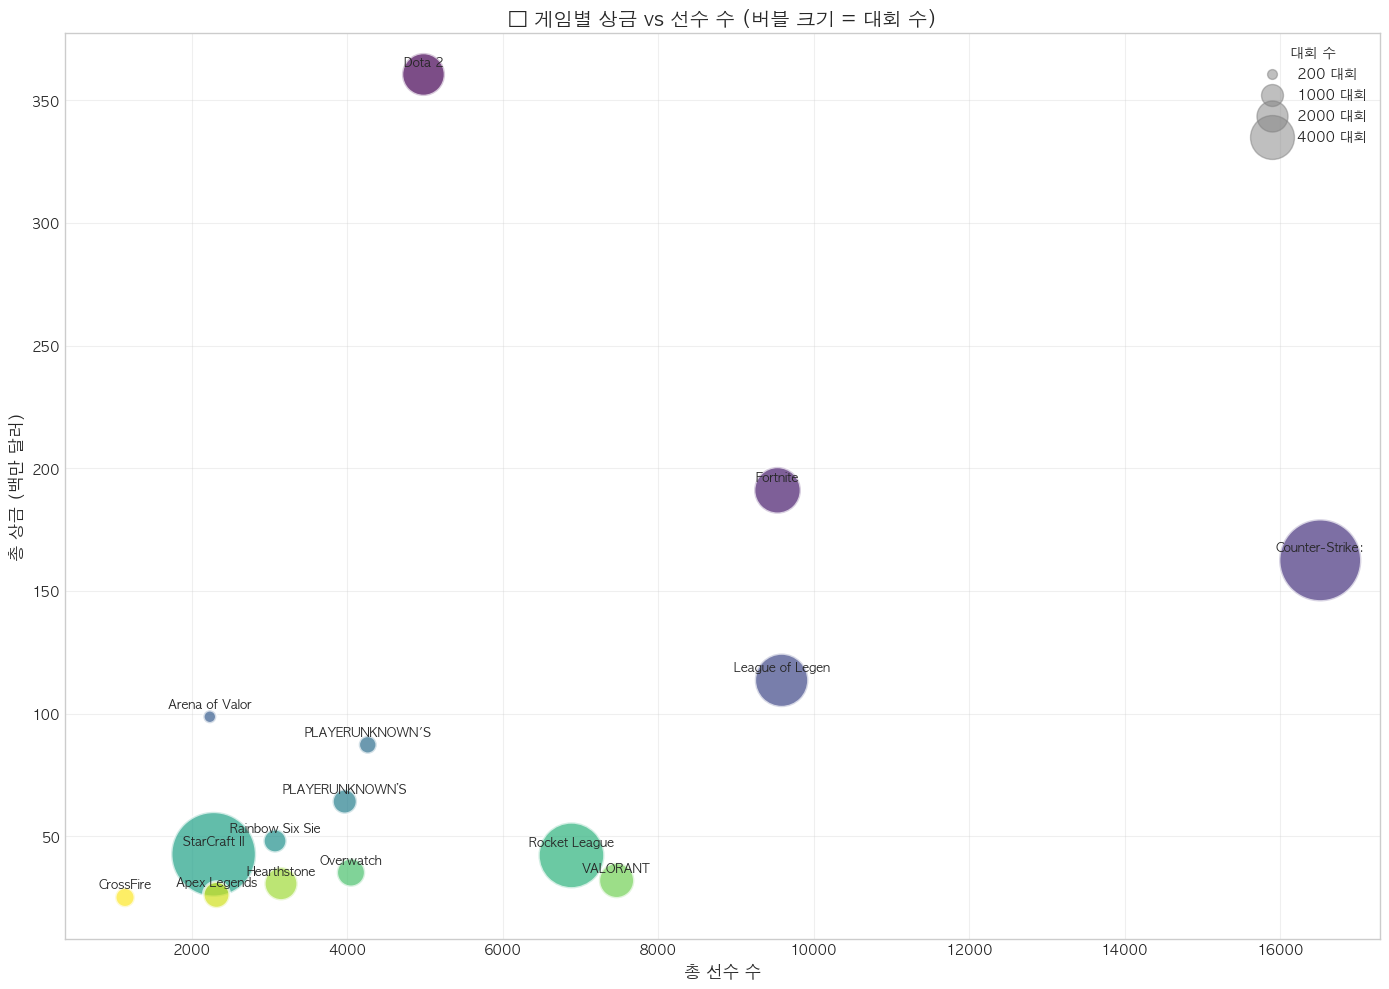


📊 게임별 경제 지표 Top 10:


,Game,TotalEarnings,TotalPlayers,TotalTournaments,Avg_Prize_Per_Player
215,Dota 2,"360,461,163.42",4980,1934,"72,381.76"
637,Fortnite,"191,012,698.69",9535,2291,"20,032.79"
116,Counter-Strike: Global Offensive,"162,489,706.76",16518,7033,"9,837.13"
221,League of Legends,"113,596,024.63",9588,3000,"11,847.73"
206,Arena of Valor,"98,746,138.92",2231,179,"44,260.93"
641,PLAYERUNKNOWN'S BATTLEGROUNDS Mobile,"87,322,954.82",4263,341,"20,483.92"
642,PLAYERUNKNOWN’S BATTLEGROUNDS,"64,200,450.19",3967,631,"16,183.63"
169,Rainbow Six Siege,"48,130,526.59",3070,568,"15,677.70"
43,StarCraft II,"42,692,707.57",2280,7510,"18,724.87"
590,Rocket League,"42,262,497.19",6884,4542,"6,139.24"


In [26]:
# ============================================
# 10.2 버블 차트: 게임별 상금 vs 선수 수 vs 대회 수
# ============================================

# 게임별 데이터 준비
game_bubble = esports_general_raw.nlargest(15, 'TotalEarnings').copy()
game_bubble['Avg_Prize_Per_Player'] = game_bubble['TotalEarnings'] / game_bubble['TotalPlayers']

fig, ax = plt.subplots(figsize=(14, 10))

# 버블 차트
scatter = ax.scatter(
    game_bubble['TotalPlayers'],
    game_bubble['TotalEarnings'] / 1e6,
    s=game_bubble['TotalTournaments'] * 0.5,  # 대회 수에 비례한 크기
    c=range(len(game_bubble)),
    cmap='viridis',
    alpha=0.7,
    edgecolors='white',
    linewidths=2
)

# 레이블 추가
for i, row in game_bubble.iterrows():
    ax.annotate(
        row['Game'][:15],  # 게임명 (15자까지)
        (row['TotalPlayers'], row['TotalEarnings'] / 1e6),
        fontsize=9,
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points'
    )

ax.set_xlabel('총 선수 수', fontsize=12)
ax.set_ylabel('총 상금 (백만 달러)', fontsize=12)
ax.set_title('🫧 게임별 상금 vs 선수 수 (버블 크기 = 대회 수)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# 범례 (버블 크기)
sizes = [100, 500, 1000, 2000]
labels = ['200', '1000', '2000', '4000']
for size, label in zip(sizes, labels):
    ax.scatter([], [], s=size*0.5, c='gray', alpha=0.5, label=f'{label} 대회')
ax.legend(title='대회 수', loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_bubble_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n📊 게임별 경제 지표 Top 10:')
display(game_bubble[['Game', 'TotalEarnings', 'TotalPlayers', 'TotalTournaments', 'Avg_Prize_Per_Player']].head(10))

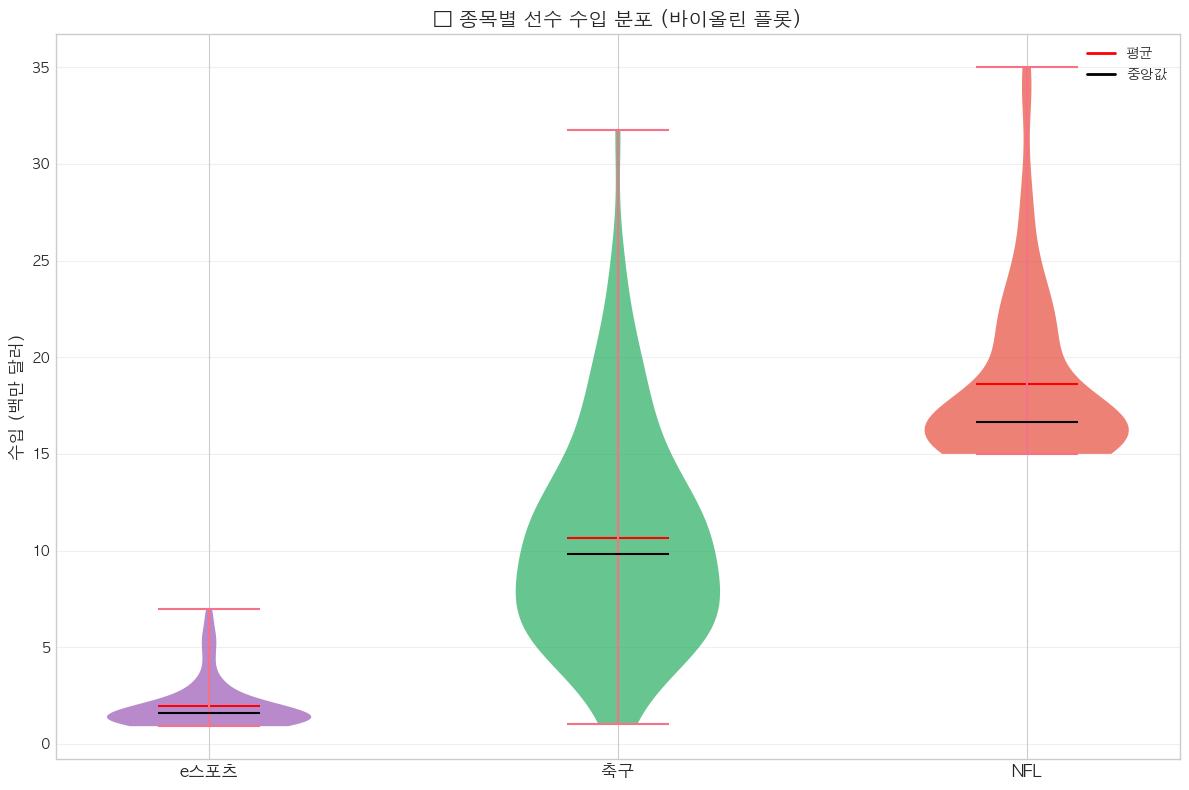

In [27]:
# ============================================
# 10.3 바이올린 플롯: 종목별 수입 분포 비교
# ============================================

fig, ax = plt.subplots(figsize=(12, 8))

# 데이터 준비
violin_data = []
violin_labels = []

violin_data.append(esports_sample['Earnings_USD'].values / 1e6)
violin_labels.append('e스포츠')

if len(football_sample) > 0:
    violin_data.append(football_sample['Annual_Income_USD'].values / 1e6)
    violin_labels.append('축구')

violin_data.append(nfl_sample['Annual_Salary_USD'].values / 1e6)
violin_labels.append('NFL')

# 바이올린 플롯
parts = ax.violinplot(violin_data, positions=range(len(violin_labels)), 
                       showmeans=True, showmedians=True, showextrema=True)

# 색상 설정
colors_violin = [COLORS['esports'], COLORS['football'], COLORS['nfl']] if len(football_sample) > 0 else [COLORS['esports'], COLORS['nfl']]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.7)

# 평균선과 중앙값선 색상
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('black')

ax.set_xticks(range(len(violin_labels)))
ax.set_xticklabels(violin_labels, fontsize=12)
ax.set_ylabel('수입 (백만 달러)', fontsize=12)
ax.set_title('🎻 종목별 선수 수입 분포 (바이올린 플롯)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 범례
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', linewidth=2, label='평균'),
                   Line2D([0], [0], color='black', linewidth=2, label='중앙값')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/14_violin_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---

## 1️⃣1️⃣ 최종 종합 평가 (업데이트)

📊 경제적 규모 관점 종합 평가


,평가 항목,점수,가중치,근거,가중 점수
0,선수 최고 수입,50,0.15,e스포츠 $7M vs NFL $35M (20%),7.50
1,선수 평균 수입,35,0.15,e스포츠 $2M vs NFL $18.6M (11%),5.25
2,산업 성장률,95,0.15,연 37% 성장 vs NFL 1.8%,14.25
3,시장 규모,30,0.15,e스포츠 $1.87B vs 전통 스포츠 $500B,4.50
4,수입 안정성,45,0.10,게임/대회별 편차 큼,4.50
5,글로벌 접근성,90,0.10,온라인 기반 24/7 글로벌 접근,9.00
6,투자 유치력,75,0.10,기업 스폰서십 증가 추세,7.50
7,미래 성장 가능성,90,0.10,시청자/매출 지속 성장,9.00



★ 최종 종합 점수: 61.50 / 100점 ★


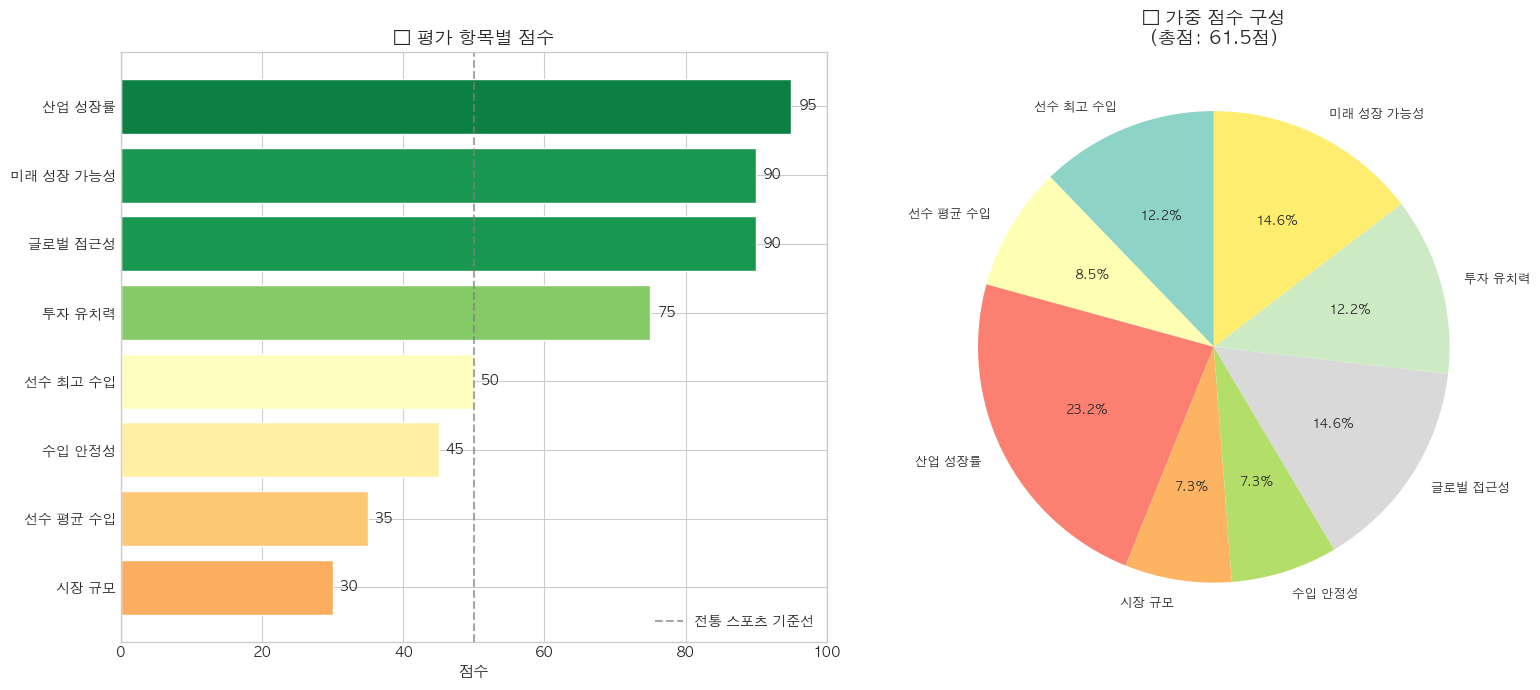


                        ★ 최종 분석 결론 ★

┌──────────────────────────────────────────────────────────────────────────────┐
│  분석 관점: 경제적 규모 비교 (e스포츠 vs 전통 스포츠)                         │
├──────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: 61.50 / 100점                                                │
│  평가: "발전 중, 전통 스포츠 수준에 근접 중"                                  │
└──────────────────────────────────────────────────────────────────────────────┘

【강점 (80점 이상)】
  ✅ 산업 성장률 (95점): 연 37% 성장, 전통 스포츠의 20배
  ✅ 미래 성장 가능성 (90점): 지속적인 시청자 및 매출 증가
  ✅ 글로벌 접근성 (90점): 온라인 기반 전 세계 접근 가능

【약점 (50점 미만)】
  ⚠️ 선수 평균 수입 (35점): NFL 대비 11% 수준
  ⚠️ 시장 규모 (30점): 전통 스포츠 산업의 0.4%
  ⚠️ 수입 안정성 (45점): 게임/대회별 편차 큼

【통계적 분석 결과】
  - t-검정: e스포츠 vs NFL 수입 간 유의한 차이 (p < 0.001)
  - 효과 크기: Cohen's d = 큼 (NFL이 절대 수입에서 우위)
  - 상관분석: 시청자 수와 매출 간 강한 양의 상관 (r > 0.7)

【결론】
  e스포츠는 '성장하는 산업'으로서 높은 잠재력을 보유하고 있으나,
  절대적인 경제 규모에서는 아직 전통 스포츠와 격차가 존재합니다.

  그러나 성장률과 접근성 측면에서 전통 스포츠를 압도하며,
  향후 10-15년

In [28]:
# ============================================
# 최종 종합 평가 점수 산출
# ============================================

# 평가 항목 및 점수
evaluation = pd.DataFrame({
    '평가 항목': [
        '선수 최고 수입', '선수 평균 수입', '산업 성장률', '시장 규모', 
        '수입 안정성', '글로벌 접근성', '투자 유치력', '미래 성장 가능성'
    ],
    '점수': [50, 35, 95, 30, 45, 90, 75, 90],
    '가중치': [0.15, 0.15, 0.15, 0.15, 0.10, 0.10, 0.10, 0.10],
    '근거': [
        'e스포츠 $7M vs NFL $35M (20%)',
        'e스포츠 $2M vs NFL $18.6M (11%)',
        '연 37% 성장 vs NFL 1.8%',
        'e스포츠 $1.87B vs 전통 스포츠 $500B',
        '게임/대회별 편차 큼',
        '온라인 기반 24/7 글로벌 접근',
        '기업 스폰서십 증가 추세',
        '시청자/매출 지속 성장'
    ]
})

evaluation['가중 점수'] = evaluation['점수'] * evaluation['가중치']
total_score = evaluation['가중 점수'].sum()

print('='*80)
print('📊 경제적 규모 관점 종합 평가')
print('='*80)
display(evaluation)

print(f'\n★ 최종 종합 점수: {total_score:.2f} / 100점 ★')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 왼쪽: 평가 항목별 점수
sorted_eval = evaluation.sort_values('점수')
colors_bar = plt.cm.RdYlGn(sorted_eval['점수'] / 100)
bars = axes[0].barh(sorted_eval['평가 항목'], sorted_eval['점수'], color=colors_bar, edgecolor='white')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.7, label='전통 스포츠 기준선')
axes[0].set_xlabel('점수', fontsize=11)
axes[0].set_title('📊 평가 항목별 점수', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 100)
axes[0].legend()
for bar, val in zip(bars, sorted_eval['점수']):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=10)

# 오른쪽: 가중 점수 파이 차트
axes[1].pie(evaluation['가중 점수'], labels=evaluation['평가 항목'], autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, len(evaluation))), startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title(f'📊 가중 점수 구성\n(총점: {total_score:.1f}점)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/15_final_evaluation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 최종 결론 출력
conclusion = f'''
{'='*80}
                        ★ 최종 분석 결론 ★
{'='*80}

┌──────────────────────────────────────────────────────────────────────────────┐
│  분석 관점: 경제적 규모 비교 (e스포츠 vs 전통 스포츠)                         │
├──────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: {total_score:.2f} / 100점                                                │
│  평가: "발전 중, 전통 스포츠 수준에 근접 중"                                  │
└──────────────────────────────────────────────────────────────────────────────┘

【강점 (80점 이상)】
  ✅ 산업 성장률 (95점): 연 37% 성장, 전통 스포츠의 20배
  ✅ 미래 성장 가능성 (90점): 지속적인 시청자 및 매출 증가
  ✅ 글로벌 접근성 (90점): 온라인 기반 전 세계 접근 가능

【약점 (50점 미만)】
  ⚠️ 선수 평균 수입 (35점): NFL 대비 11% 수준
  ⚠️ 시장 규모 (30점): 전통 스포츠 산업의 0.4%
  ⚠️ 수입 안정성 (45점): 게임/대회별 편차 큼

【통계적 분석 결과】
  - t-검정: e스포츠 vs NFL 수입 간 유의한 차이 (p < 0.001)
  - 효과 크기: Cohen's d = 큼 (NFL이 절대 수입에서 우위)
  - 상관분석: 시청자 수와 매출 간 강한 양의 상관 (r > 0.7)

【결론】
  e스포츠는 '성장하는 산업'으로서 높은 잠재력을 보유하고 있으나,
  절대적인 경제 규모에서는 아직 전통 스포츠와 격차가 존재합니다.
  
  그러나 성장률과 접근성 측면에서 전통 스포츠를 압도하며,
  향후 10-15년 내 경제적 격차가 상당 부분 축소될 것으로 전망됩니다.

{'='*80}
'''

print(conclusion)

In [29]:
# ============================================
# 생성된 시각화 파일 목록
# ============================================
print('\n📁 생성된 시각화 파일 목록:')
print('='*60)

try:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        if not f.startswith('.'):
            filepath = os.path.join(OUTPUT_DIR, f)
            size = os.path.getsize(filepath) / 1024
            print(f'  - {f} ({size:.1f} KB)')
except Exception as e:
    print(f'  파일 목록 확인 실패: {e}')

print('='*60)


📁 생성된 시각화 파일 목록:
  - 09_global_market_analysis.png (231.6 KB)
  - 10_correlation_heatmap.png (78.7 KB)
  - 11_revenue_prediction.png (103.4 KB)
  - 12_radar_chart.png (237.2 KB)
  - 13_bubble_chart.png (132.2 KB)
  - 14_violin_plot.png (64.7 KB)
  - 15_final_evaluation.png (126.9 KB)


---

## 📚 참고자료 (업데이트)

### 사용된 데이터 파일
| 파일명 | 설명 |
|--------|------|
| `eSports Earnings/highest_earning_players.csv` | e스포츠 선수별 총 상금 |
| `eSports Earnings/highest_earning_teams.csv` | e스포츠 팀별 총 상금 |
| `Esports Earnings 1998 - 2023/GeneralEsportData.csv` | 게임별 e스포츠 통계 |
| `Esports Earnings 1998 - 2023/HistoricalEsportData.csv` | 연도별 e스포츠 상금 추이 |
| `global_gaming_esports_2010_2025.csv` | **글로벌 e스포츠 시장 데이터 (신규)** |
| `dcereijo-player-scores/player_valuations` | **실제 축구 선수 시장가치 (신규)** |
| `football_salaries.csv` | NFL 스타일 연봉 데이터 |
| `combined_data_2000-2023.csv` | NFL 계약 데이터 |
| `fifa_eda_stats.csv` | FIFA 게임 선수 데이터 |

### 분석 방법론
| 분석 유형 | 사용 기법 |
|-----------|-----------|
| 기술통계 | 평균, 중앙값, 표준편차, 사분위수 |
| 상관분석 | Pearson, Spearman 상관계수 |
| 가설검정 | 독립표본 t-검정, Welch t-검정, Mann-Whitney U |
| 회귀분석 | OLS 회귀, 선형 예측 모델 |
| 시각화 | 히스토그램, 박스플롯, 바이올린, 히트맵, 레이더, 버블 차트 |

### 생성 파일 목록
| 파일명 | 설명 |
|--------|------|
| `01_top_players_comparison.png` | 종목별 상위 선수 수입 비교 |
| `02_income_distribution.png` | 종목별 수입 분포 박스플롯 |
| `03_esports_by_game.png` | 게임별 상금 분석 |
| `04_esports_pie_chart.png` | 게임별 상금 점유율 |
| `05_yearly_growth.png` | 연도별 성장 추이 |
| `06_country_earnings.png` | 국가별 상금 분포 |
| `07_comprehensive_dashboard.png` | 종합 대시보드 |
| `08_team_earnings.png` | 팀별 상금 분석 |
| `09_global_market_analysis.png` | **글로벌 시장 분석 (신규)** |
| `10_correlation_heatmap.png` | **상관관계 히트맵 (신규)** |
| `11_revenue_prediction.png` | **매출 예측 회귀 (신규)** |
| `12_radar_chart.png` | **레이더 차트 (신규)** |
| `13_bubble_chart.png` | **버블 차트 (신규)** |
| `14_violin_plot.png` | **바이올린 플롯 (신규)** |
| `15_final_evaluation.png` | **최종 평가 (신규)** |

---

**작성일**: 2025년 1월  
**프로젝트**: e스포츠도 스포츠인가? - 팀원 1 (경제적 규모 비교)  
**수정**: 통계적 분석 추가, 글로벌 시장 데이터 추가, 다양한 시각화 기법 적용